# Classification

Classification is a technique used to **identify the category** of new observations on the basis of training data. In the above diagram, the green line can be identified as the **decision boundary** since we can observe instances of a different class on each side of the line. Our intention in classification would be to decide on a proper fit to the decision boundary so that we will be able to predict which class a new sample might correspond to. 

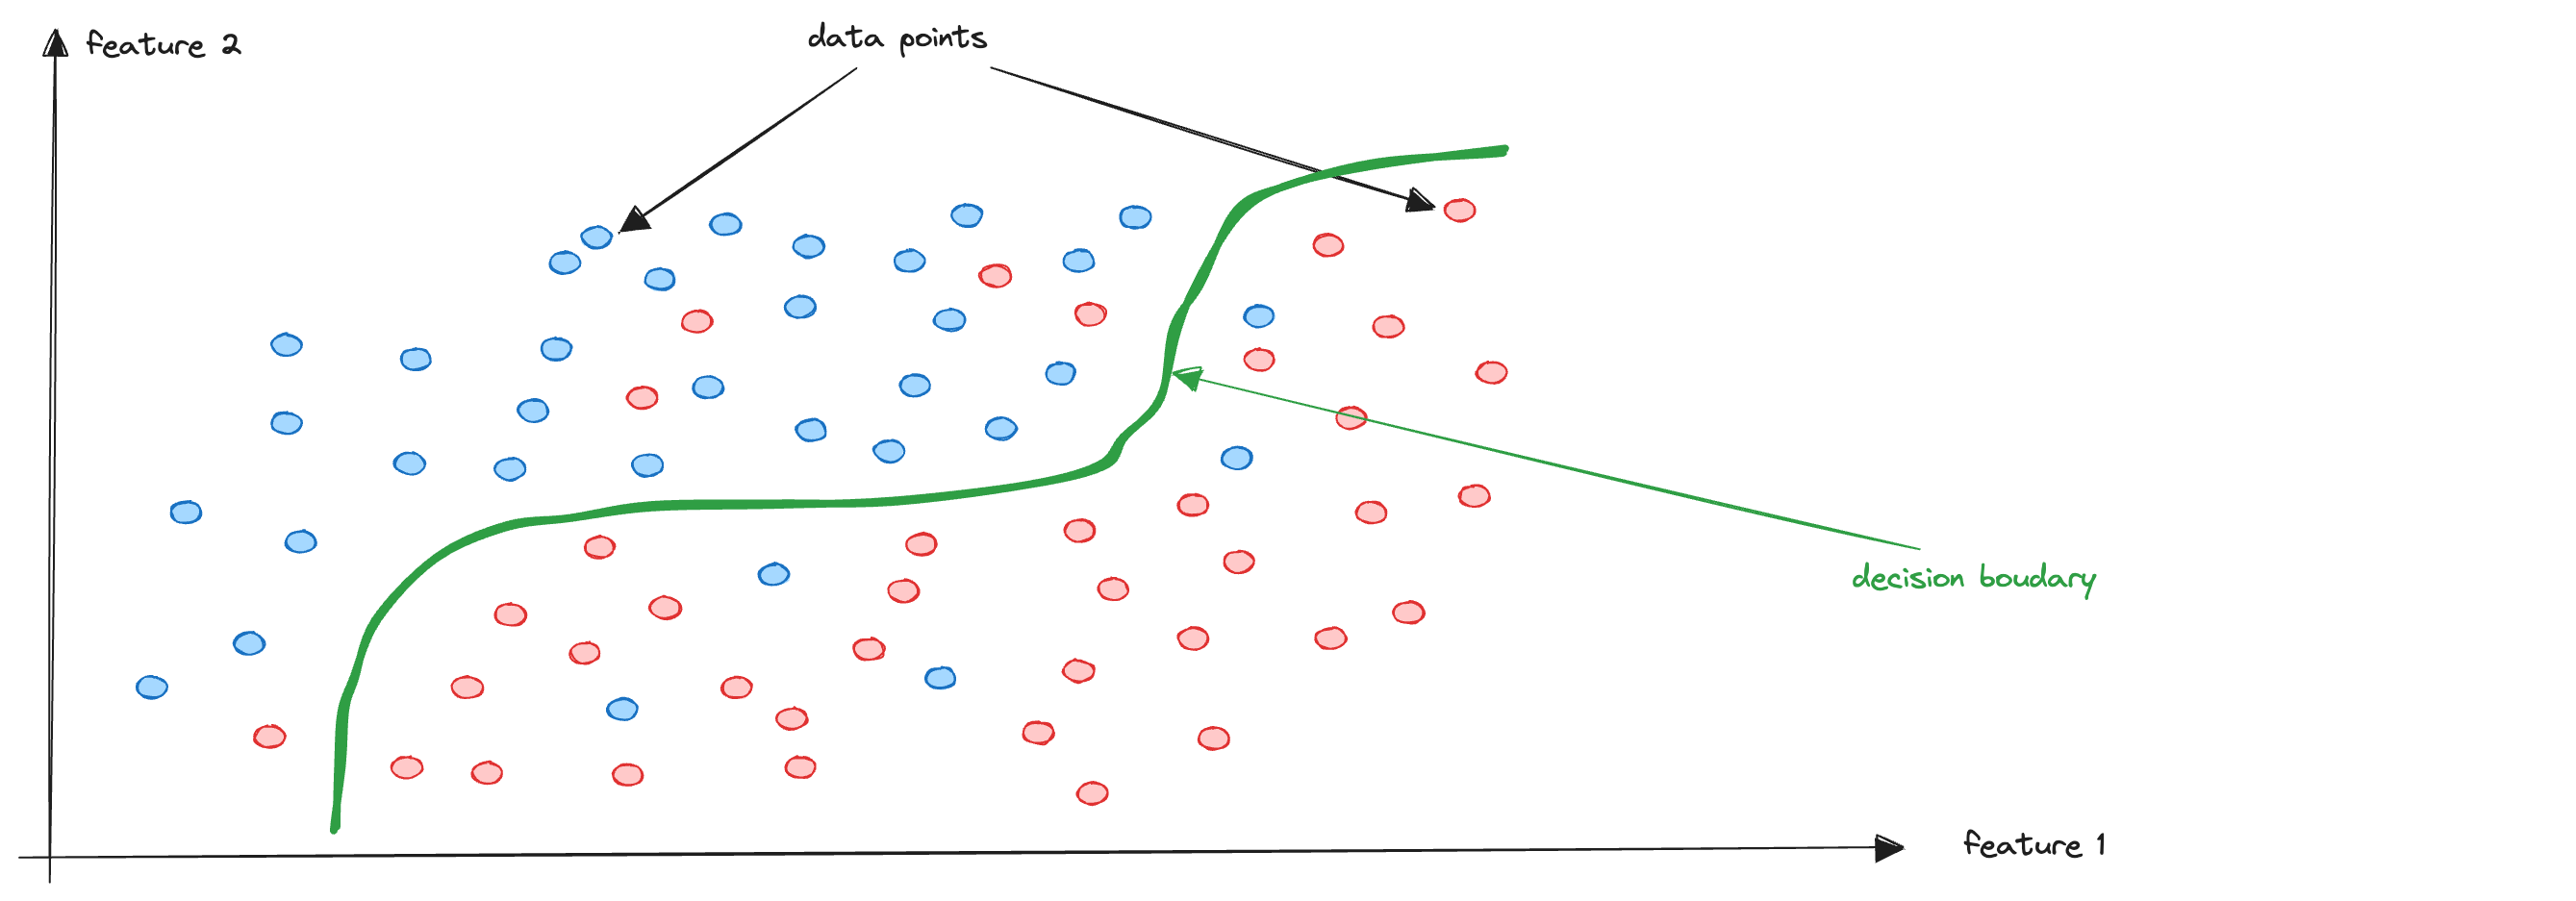

## Dataset

As a running example, we will be using the **[MNIST dataset](https://paperswithcode.com/dataset/mnist)**, which is a set of **70.000 small images of digits handwritten** by high school students and employees of the US Census Bureau. Each image is **labeled** with the digit it represents. This set has been studied so much that it is often called the “hello world” of machine learning. Each image has 784 features (28×28 pixels), and each feature simply represents one pixel’s intensity, from 0 (white) to 255 (black). Scikit-Learn provides the **fetch_openml()** helper functions to download popular datasets, also MNIST is one of them. The loaded datasets have a similar dictionary structure, including the following:
- **DESCR** describes the dataset
- **data** contains an array with one row per instance and one column per feature
- **target** contain an array with the labels

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

We can check the dataset shape and visualize some of the images to understand it better.

In [2]:
import numpy as np

print("MNIST keys:", mnist.keys())

X = mnist["data"]
y = mnist["target"]
y = y.astype(np.uint8)

print("Features: ", X.shape)
print("Labels: ", y.shape)

MNIST keys: dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
Features:  (70000, 784)
Labels:  (70000,)


Let’s take one digit from the dataset, **reshape** it to a 28×28 array, and display it using Matplotlib’s **imshow()** function:

Features: 


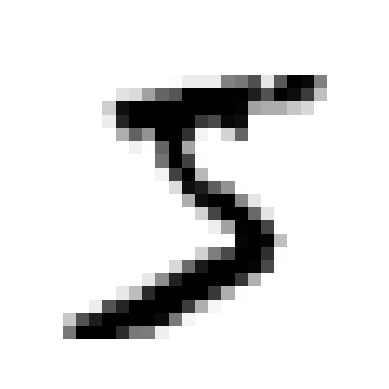

Label:  5


In [3]:
import matplotlib.pyplot as plt

print("Features: ")
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

print("Label: ", y[0])

Plot some more examples:

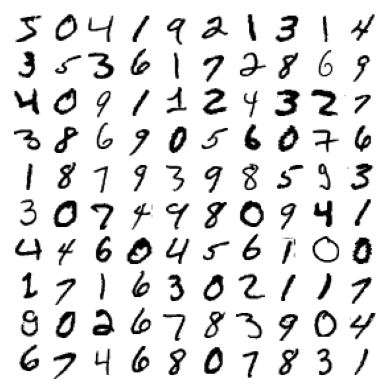

In [4]:
instances = X[:100]

images_per_row = 10
n_rows = len(instances) // images_per_row
n_images = n_rows * images_per_row

images = [instance.reshape(28,28) for instance in instances]
matrix_images = []
for row in range(n_rows):
    row_images = images[row * images_per_row : (row + 1) * images_per_row]
    matrix_images.append(np.concatenate(row_images, axis=1))

final_image = np.concatenate(matrix_images, axis=0)

plt.imshow(final_image, cmap="binary")
plt.axis("off")
plt.show()

As in regression, we have to create a test set and set it aside before  inspecting the data closely. The MNIST dataset is already split into a **training set** (the first 60.000 images) and a **test set** (the last 10.000 images). The training set is already **shuffled**, which is good because this guarantees that all cross-validation folds will be similar (we don’t want to have some folds missing some digits). Moreover, some learning algorithms are sensitive to the order of the training instances, and they perform poorly if they get many similar instances in a row. 

In [5]:
X_train, y_train = X[:60000], y[:60000]
X_test, y_test = X[60000:], y[60000:]

## Training a classifier

We start simplifying the problem and we try to build a classifier **to identify only one digit** (e.g. "5"). This detector will be an example of a **binary classifier**, capable of distinguishing between just two classes (in that case "5" and "not 5"). A good place to start is a **linear model**. In this case, we are making the assumption that **the two classes can be separated by a straight line**, or better and more generally by a **hyperplane**. We can use the Scikit-Learn’s **SGDClassifier** class (which is a regularized linear model with stochastic gradient descent learning). This classifier has the advantage of being capable of handling very large datasets efficiently, since it deals with training instances independently, one at a time.

In [6]:
from sklearn.linear_model import SGDClassifier

y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

Now we can use it to detect images of the number 5:

In [7]:
prediction = sgd_clf.predict([some_digit])

print("Prediction: ", prediction)

Prediction:  [ True]


The classifier guesses that this image represents a 5 (True). Now, we need to evaluate the model performances.

## Performance Measure

Evaluating a classifier is often **significantly trickier than evaluating a regressor**. In this case we cannot use **RMSE**, because we don't have a continuous measure, we have correct and predicted labels to be compared. We need to define several evaluation metrics specific for this type of problem.

### Accuracy

Informally, **accuracy** is what we usually mean, when we use that term: the ratio of correct predictions to the total number of samples:

$\displaystyle \text{accuracy}=\frac{\text{number of correct prediction}}{\text{total number of predictions made}} $

It **works well if there are equal number of samples belonging to each class** and if the **cost of misclassification of the samples are equal**. However, it can be misleading and it can gives us a **false sense of achieving good results**. For example, if we are classifying medial data to find a rare but fatal disease, the cost of failing to diagnose the disease of a sick person is much higher than the cost of sending a healthy person to more tests.

We can use **K-fold cross-validation** in order to calculate the accuracy of our linear model on the MNIST dataset. Remember that this means splitting the training set into K folds (e.g. 3), then making predictions and evaluating them on each fold using a model trained on the remaining folds.

In [8]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(sgd_clf, X_train, y_train_5, 
                        cv=3, scoring="accuracy")

print("Cross validation score: ", score)

Cross validation score:  [0.95035 0.96035 0.9604 ]


Wow! Above 95% accuracy on all cross validation folds? This looks amazing? Well, before we get too excited, let’s look at a very dumb classifier that just classifies every single image in the "not-5" class:

In [9]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)
    
never_5_clf = Never5Classifier()

In [10]:
score = cross_val_score(never_5_clf, X_train, y_train_5, 
                        cv=3, scoring="accuracy")

print("Cross validation score of dumb classifier: ", score)

Cross validation score of dumb classifier:  [0.91125 0.90855 0.90915]


That’s right, it has over 90% accuracy! 
This is simply because only about 10% of the images are 5s, so if you always guess that an image is not a 5, you will be right about 90% of the time. This demonstrates why **accuracy is generally not the preferred performance measure for classifiers**, especially when you are dealing with **skewed datasets** (some classes are much more frequent than others).

### Confusion Matrix

A much better way to evaluate the performance of a classifier is to look at its **confusion matrix**. The idea is to count the number of times instances of class are misclassified as another class. 

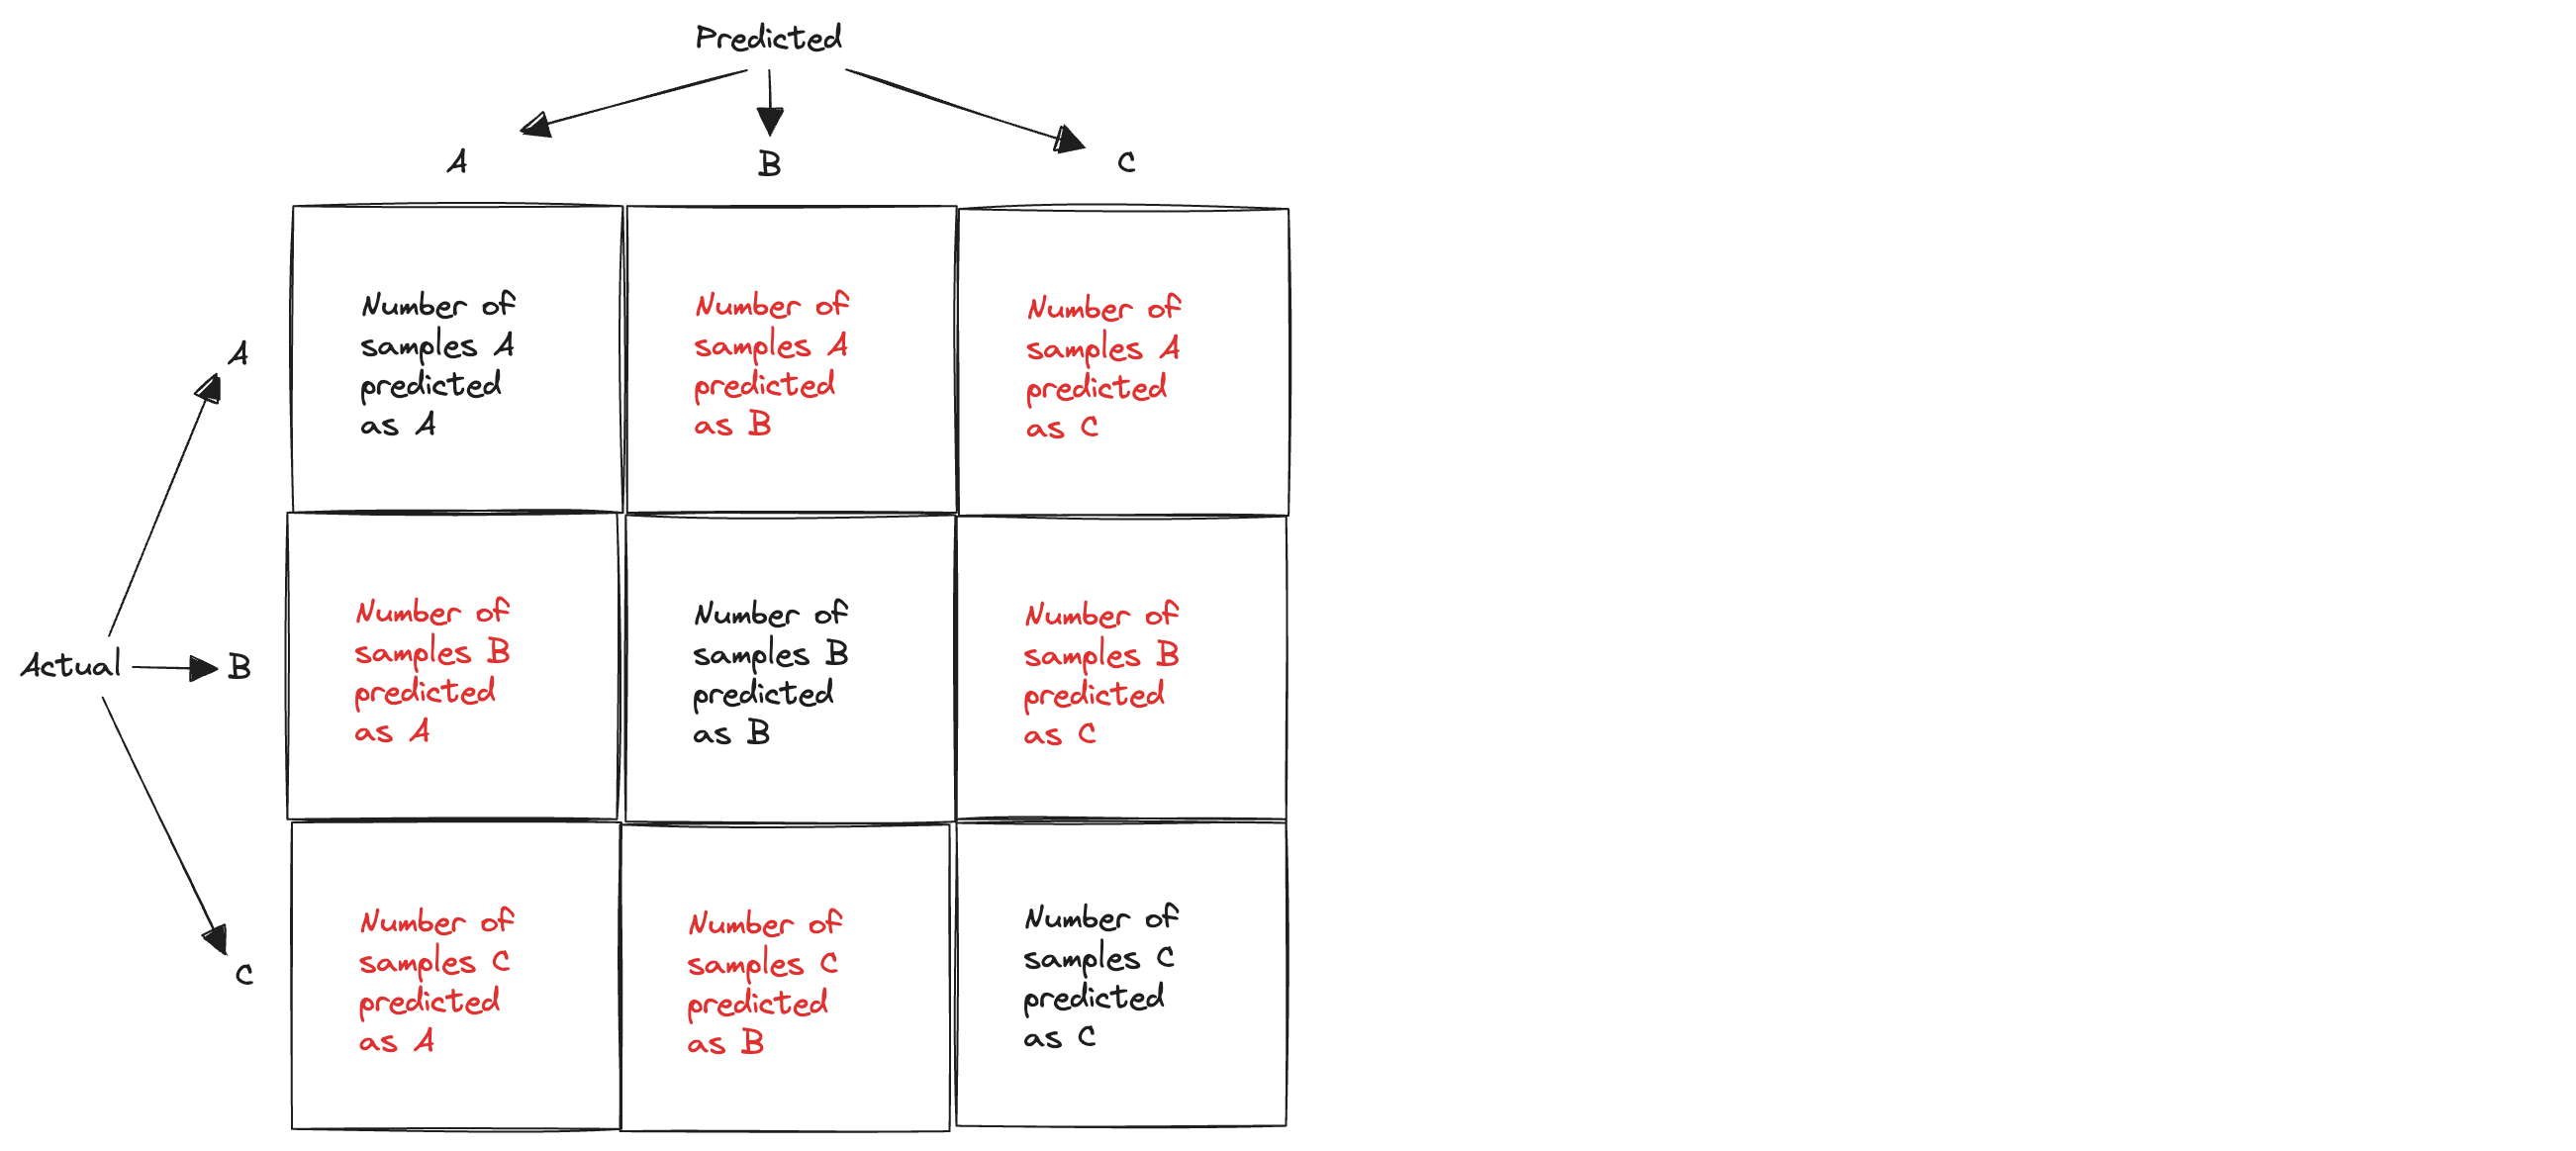

To compute it, we need a set of predictions so that they can be compared to the actual targets. We can use the **cross_val_predict()** function, it  performs K-fold cross-validation, but it returns the predictions made on each fold, so we get a **clean predictions** (made by a model that never saw the data during training).

In [11]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

Now we get the confusion matrix using the **confusion_matrix()** function.

In [12]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

Each **row represents an actual class**, while **each column represents a predicted class**. When we are dealing with a binary classifier, we can have a more concise representation of the confusion matrix using the following terms: 

- **true negatives (TN)**: the number of negative instances that were correctly classified as negative (in the example, the "non-5" images correctly classified as "non-5")
- **false positives (FP)**: the number of negative instances that were wrongly classified as positive (in the example, the "non-5" images wrongly classified as "5")
- **false negatives (FN)**: the number of positive instances that were wrongly classified as negative (in the example, the "5" images wrongly classified as "non-5")
- **true positives (TP)**: the number of positive instances that were correctly classified as positive (in the example, the "5" images correctly classified as "5")

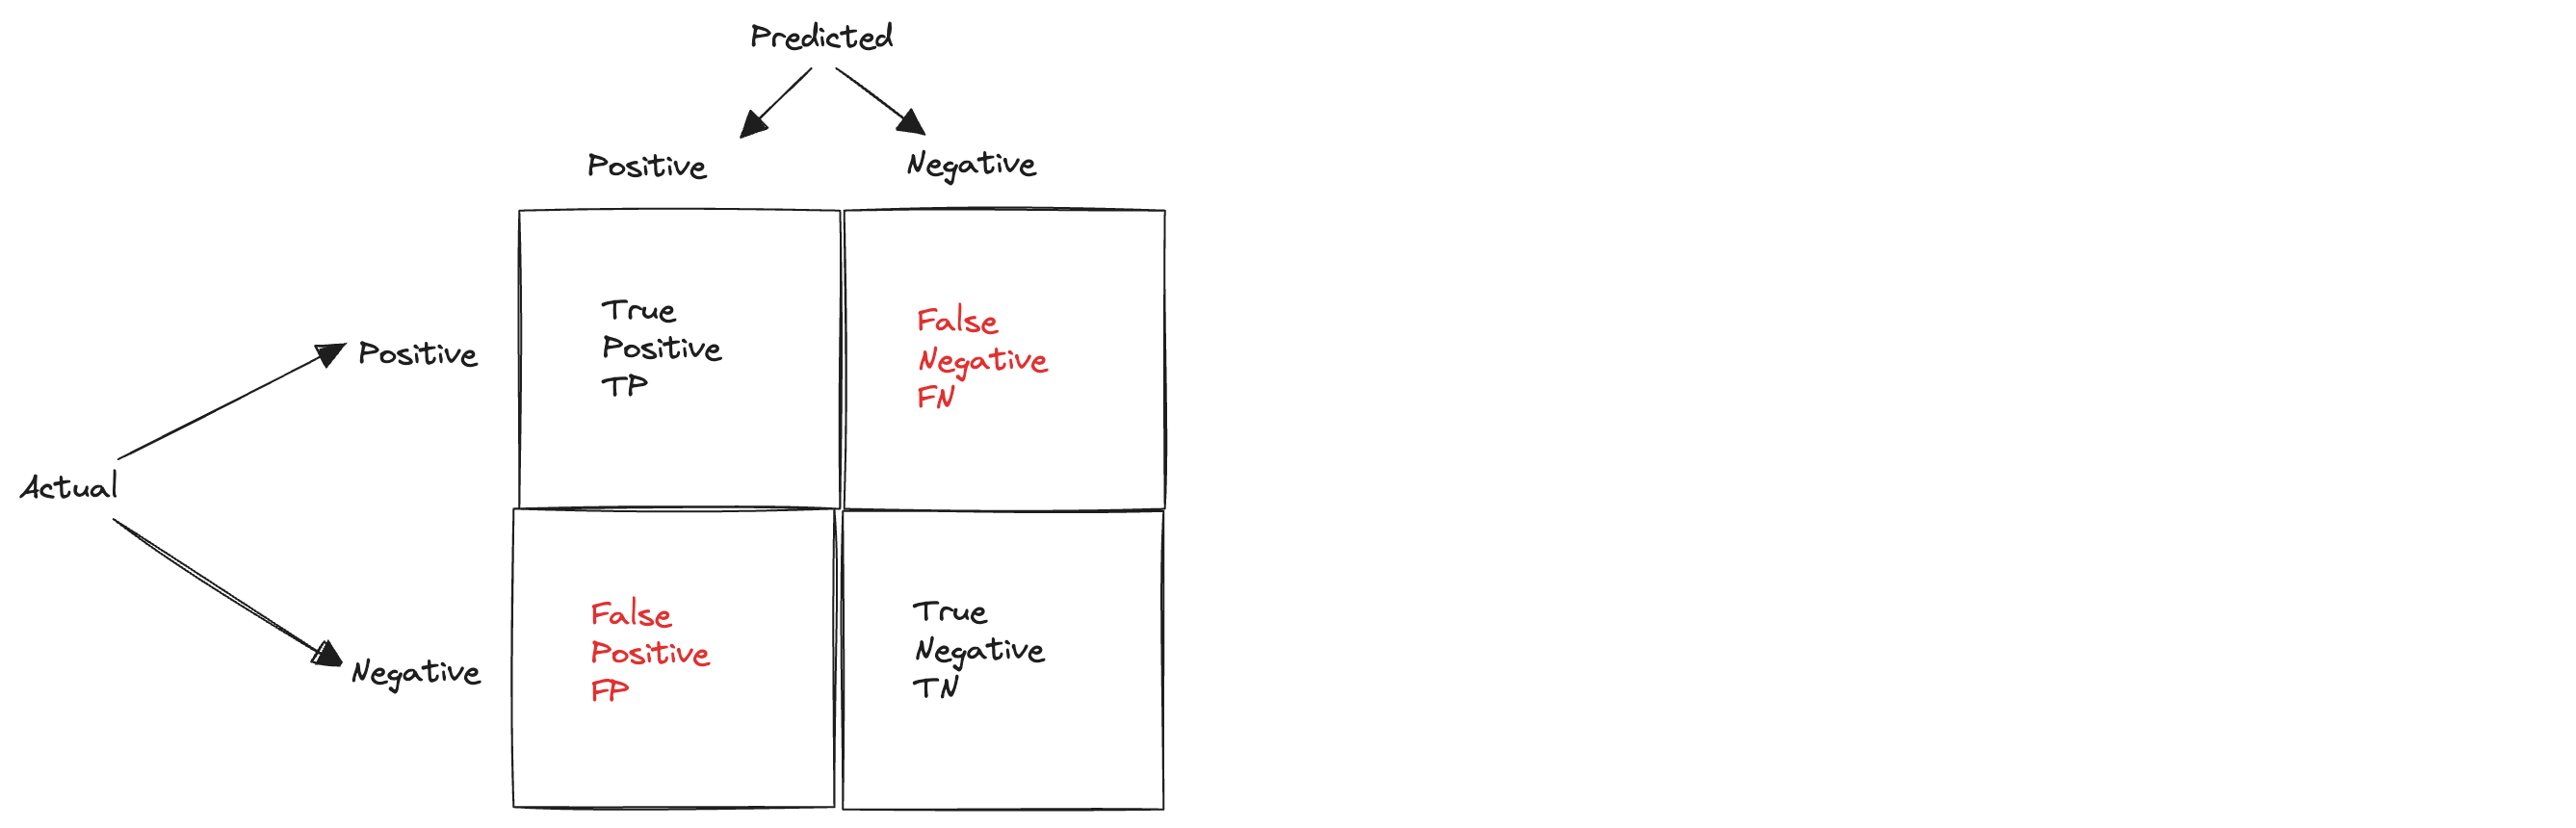

A **perfect classifier** would have only true positives and true negatives.

In [13]:
y_train_perfect_predictions = y_train_5

confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

### Precision, Recall and F1

Sometimes you may prefer a **more concise metric**, in order to have a single number to evaluate the classifier, that allow you to compare different models. The **Precision** is the fraction of relevant instances among the retrieved instances, while the **recall** is the fraction of relevant instances that have been retrieved over the total amount of relevant instances.

$\displaystyle precision = \frac{TP}{TP + FP}$

$\displaystyle recall = \frac{TP}{TP + FN}$

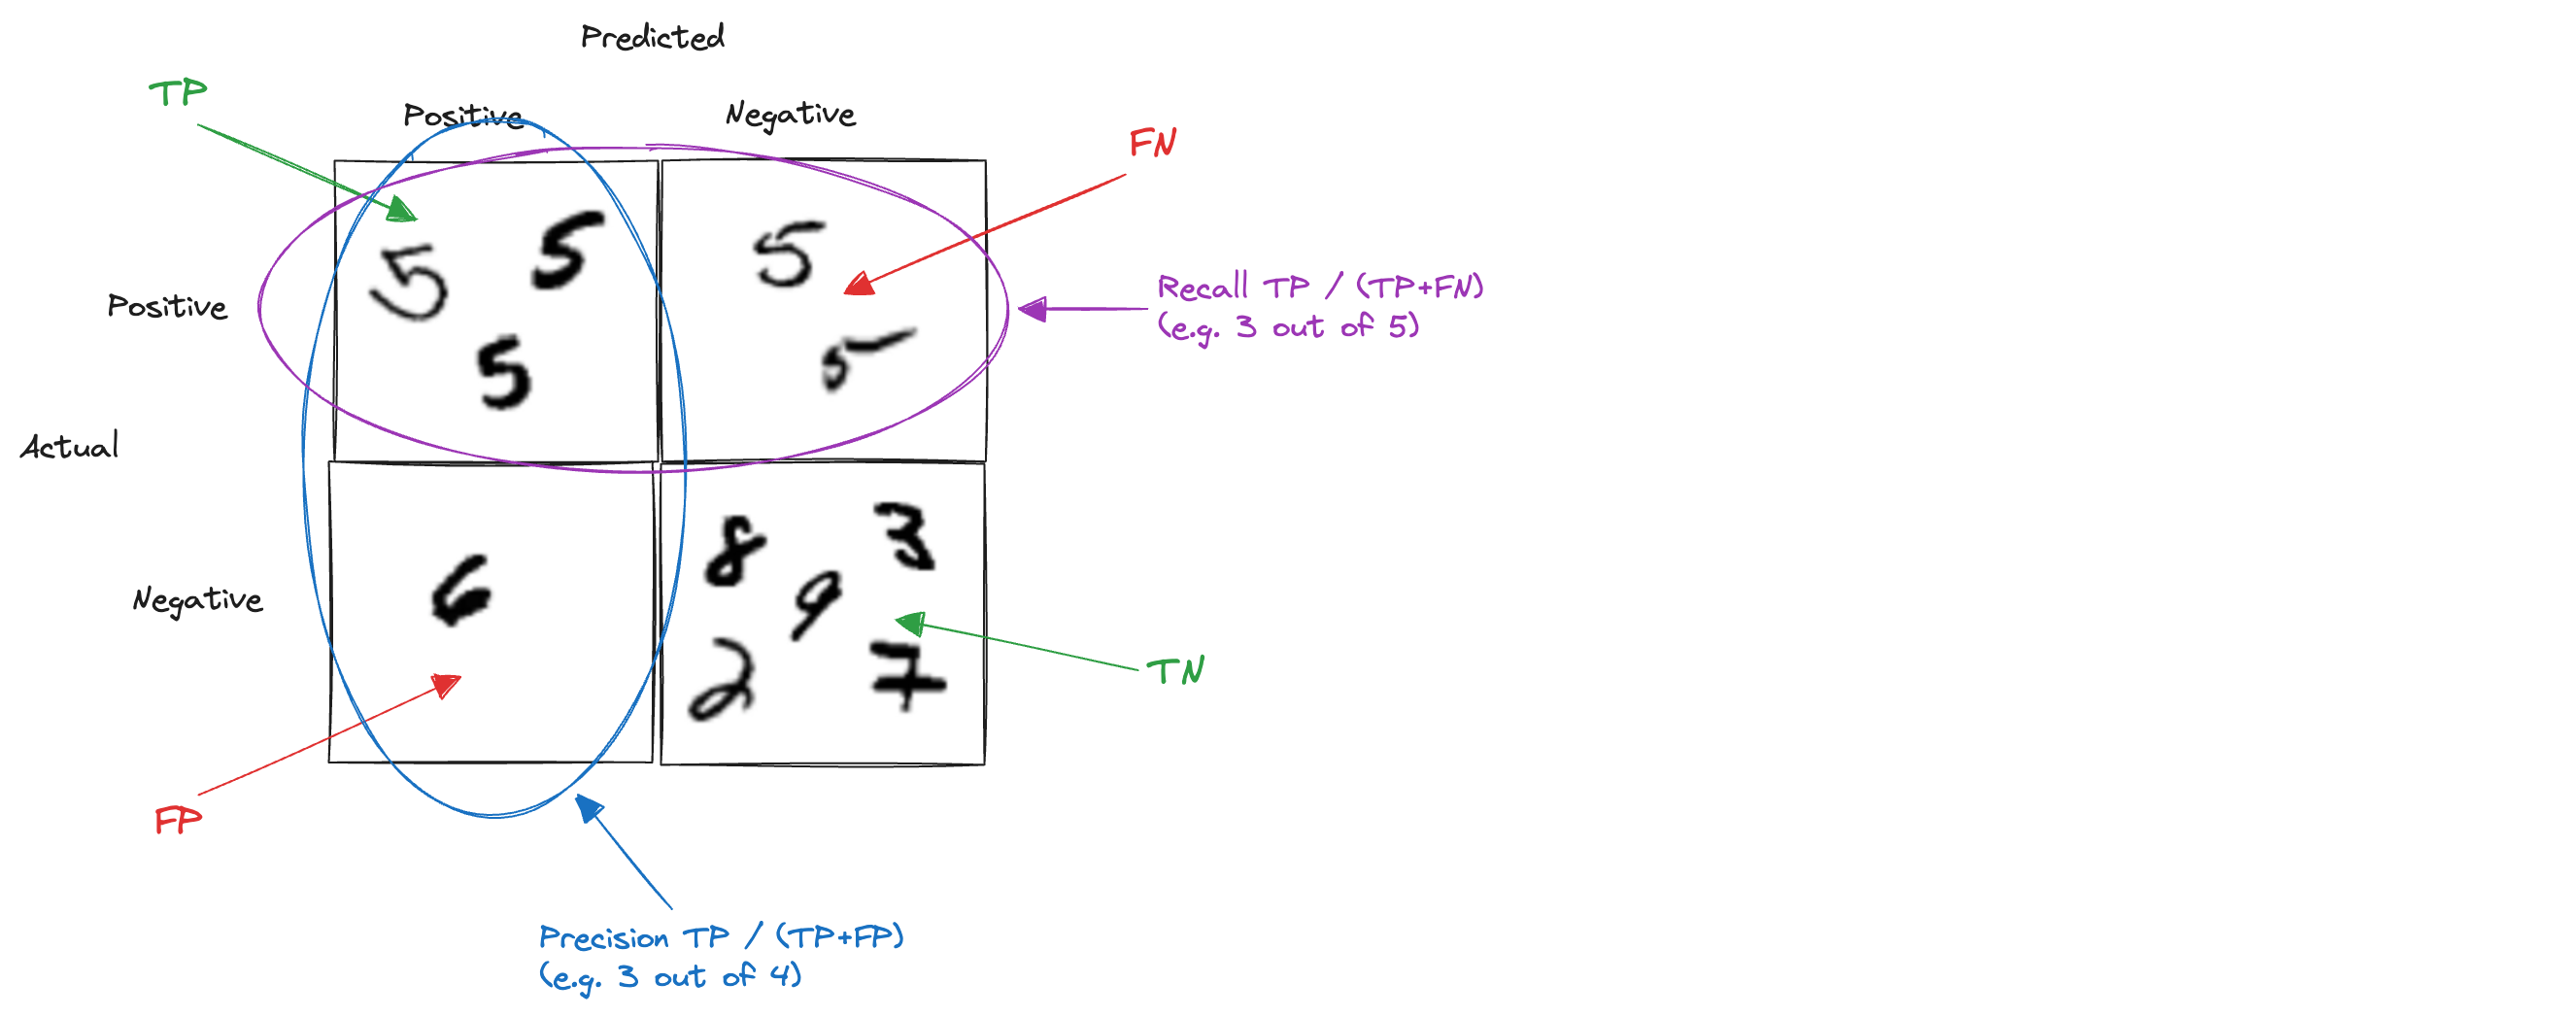

Scikit-Learn provides several functions to compute classifier metrics, including precision and recall.

In [14]:
from sklearn.metrics import precision_score, recall_score

print(precision_score(y_train_5, y_train_pred))
print(recall_score(y_train_5, y_train_pred))

0.8370879772350012
0.6511713705958311


It is often convenient to combine precision and recall into a single metric called the **F1 score**, in particular if you need a simple way to compare two classifiers. F1 Score is the **Harmonic Mean** between precision and recall (a kind of average, expressed as the reciprocal of the arithmetic mean of the reciprocals of the given set of observations). The **range for F1 Score is [0,1]**. It tells us how **precise** our classifier is (**how many instances it classifies correctly**), as well as how **robust** it is (**it does not miss a significant number of instances**). High precision but lower recall, gives us an extremely accurate, but it then misses a large number of instances that are difficult to classify. The greater the F1 Score, the better is the performance of our model. Mathematically, it can be expressed as :

$\displaystyle F_1 = \frac{2}{\frac{1}{precision} + \frac{1}{recall}} = 2 \times \frac{precision \times recall}{precision + recall} = \frac{TP}{TP + \frac{FN+FP}{2}}$

The harmonic mean is used instead of the standard arithmetic mean because it **better reflects the trade-off between these two metrics**, especially when their values are imbalanced. The harmonic mean gives more weight to lower values. If either precision or recall is much lower than the other, the F1 score will be closer to the smaller number. This property is important because, in most cases, a high F1 score is desired only when both precision and recall are relatively high. The arithmetic mean, on the other hand, would not penalize the disparity between the two metrics as strongly.

In [15]:
from sklearn.metrics import f1_score

print(f1_score(y_train_5, y_train_pred))

0.7325171197343846


The F1 score favors classifiers that have **similar precision and recall**. This is not always the case. For example, if we need to detect videos that are safe for kids, we probably prefer a classifier that rejects good videos (low recall) but keeps only safe ones (high precision). On the other hand, suppose we need to detect shoplifters in surveillance images: it is probably fine if our classifier has low precision as long as it has high recall (we will get a few false alerts, but almost all shoplifters will get caught). Unfortunately, **we can’t have it both ways**: increasing precision reduces recall, and vice versa. This is called the **precision/recall trade-off**. 

The classifier use a decision function: if the score is greater than a threshold, it assigns the instance to the positive class, otherwise it assigns it to the negative class. If you raise the threshold, some false positive becomes a true negative, increasing the precision, but probably some true positives becomes false negatives, decreasing recall. Conversely, lowering the threshold increases recall and reduces precision.

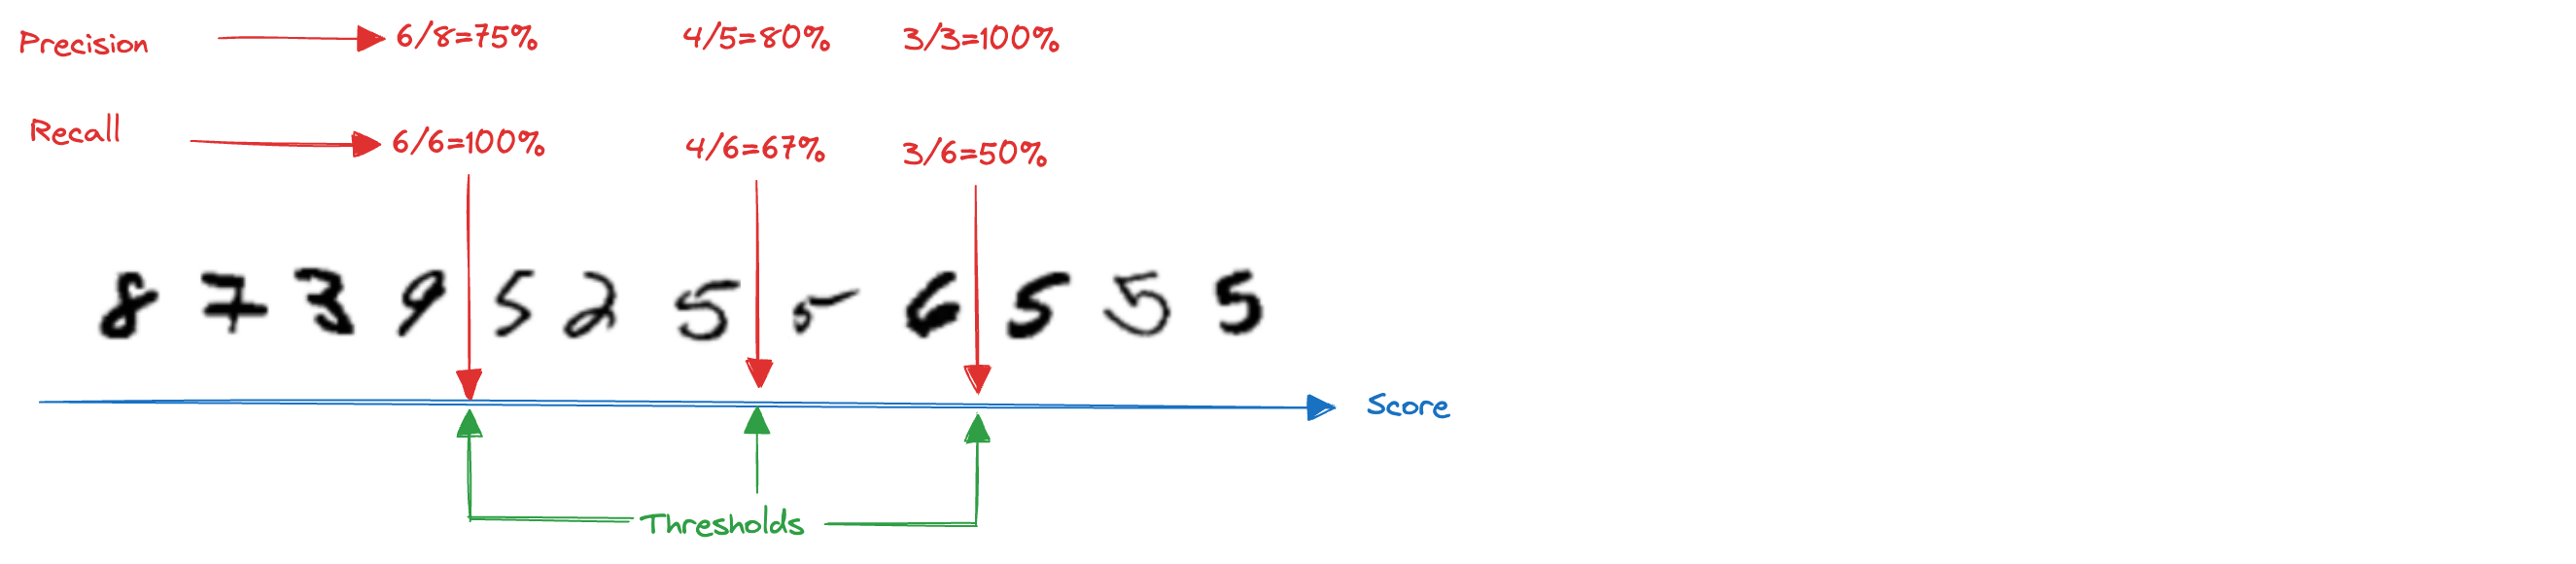

Scikit-Learn does not let to set the threshold directly, but it gives access to the **decision scores** that it uses to make predictions using the **decision_function()** method. Then we can use any threshold we want to make predictions.

In [16]:
y_scores = sgd_clf.decision_function([some_digit])
print(y_scores)

threshold = 0
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)

threshold = 8000
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)

[2164.22030239]
[ True]
[False]


How we can decide which threshold to use? First, we can use the cross_val_predict() function to get the scores of all instances in the training set, but this time specify that we want to return decision scores instead of predictions. Then, we use the **precision_recall_curve()** function to  **compute precision and recall for all possible thresholds**. Finally, we can plot precision and recall as functions of the threshold value.

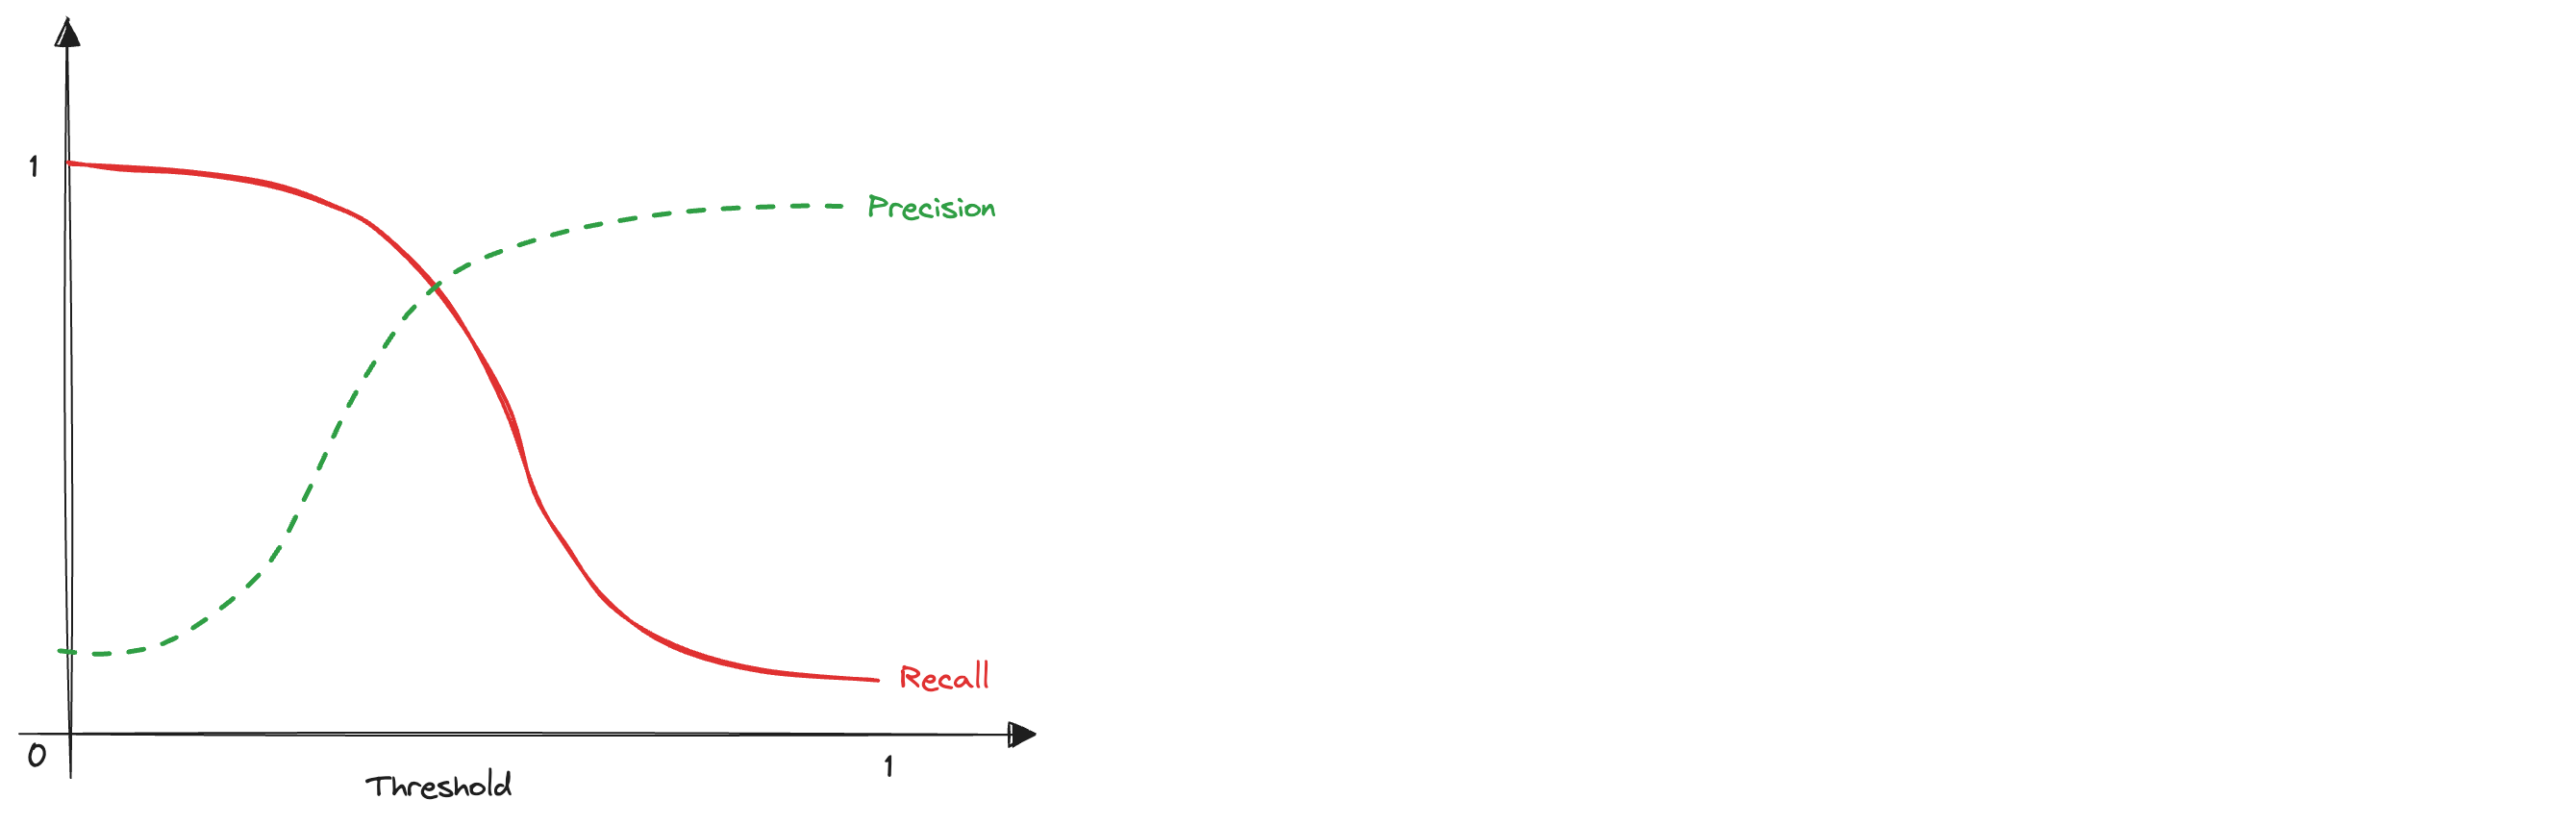

In [17]:
from sklearn.metrics import precision_recall_curve

y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

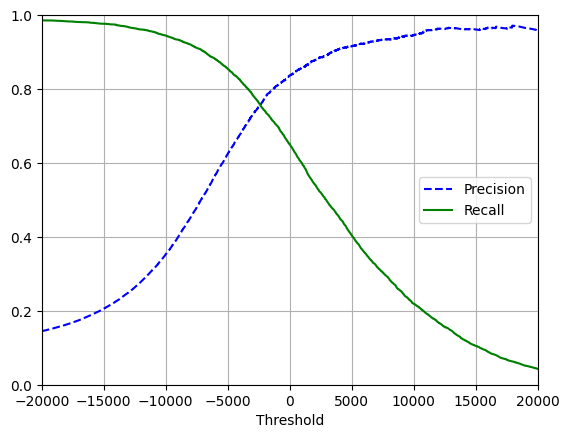

In [18]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")

plt.legend(loc="center right")
plt.xlabel("Threshold")        
plt.grid(True)                              
plt.axis([-20000, 20000, 0, 1]) 
            
plt.show()

Another way to select a good precision/recall trade-off is to **plot precision directly against recall**. The figure below shows some theoretical classifiers would plot on a precision-recall curve. The gray dotted line represents a “baseline” classifier, this classifier would simply predict that all instances belong to the positive class. The purple line represents an ideal classifier, one with perfect precision and recall at all thresholds. Nearly all real-world examples will fall somewhere between these two lines: not perfect, but providing better predictions than the baseline. A good classifier will maintain both a high precision and high recall across the graph, and **will "hug" the upper right corner** in the figure below.

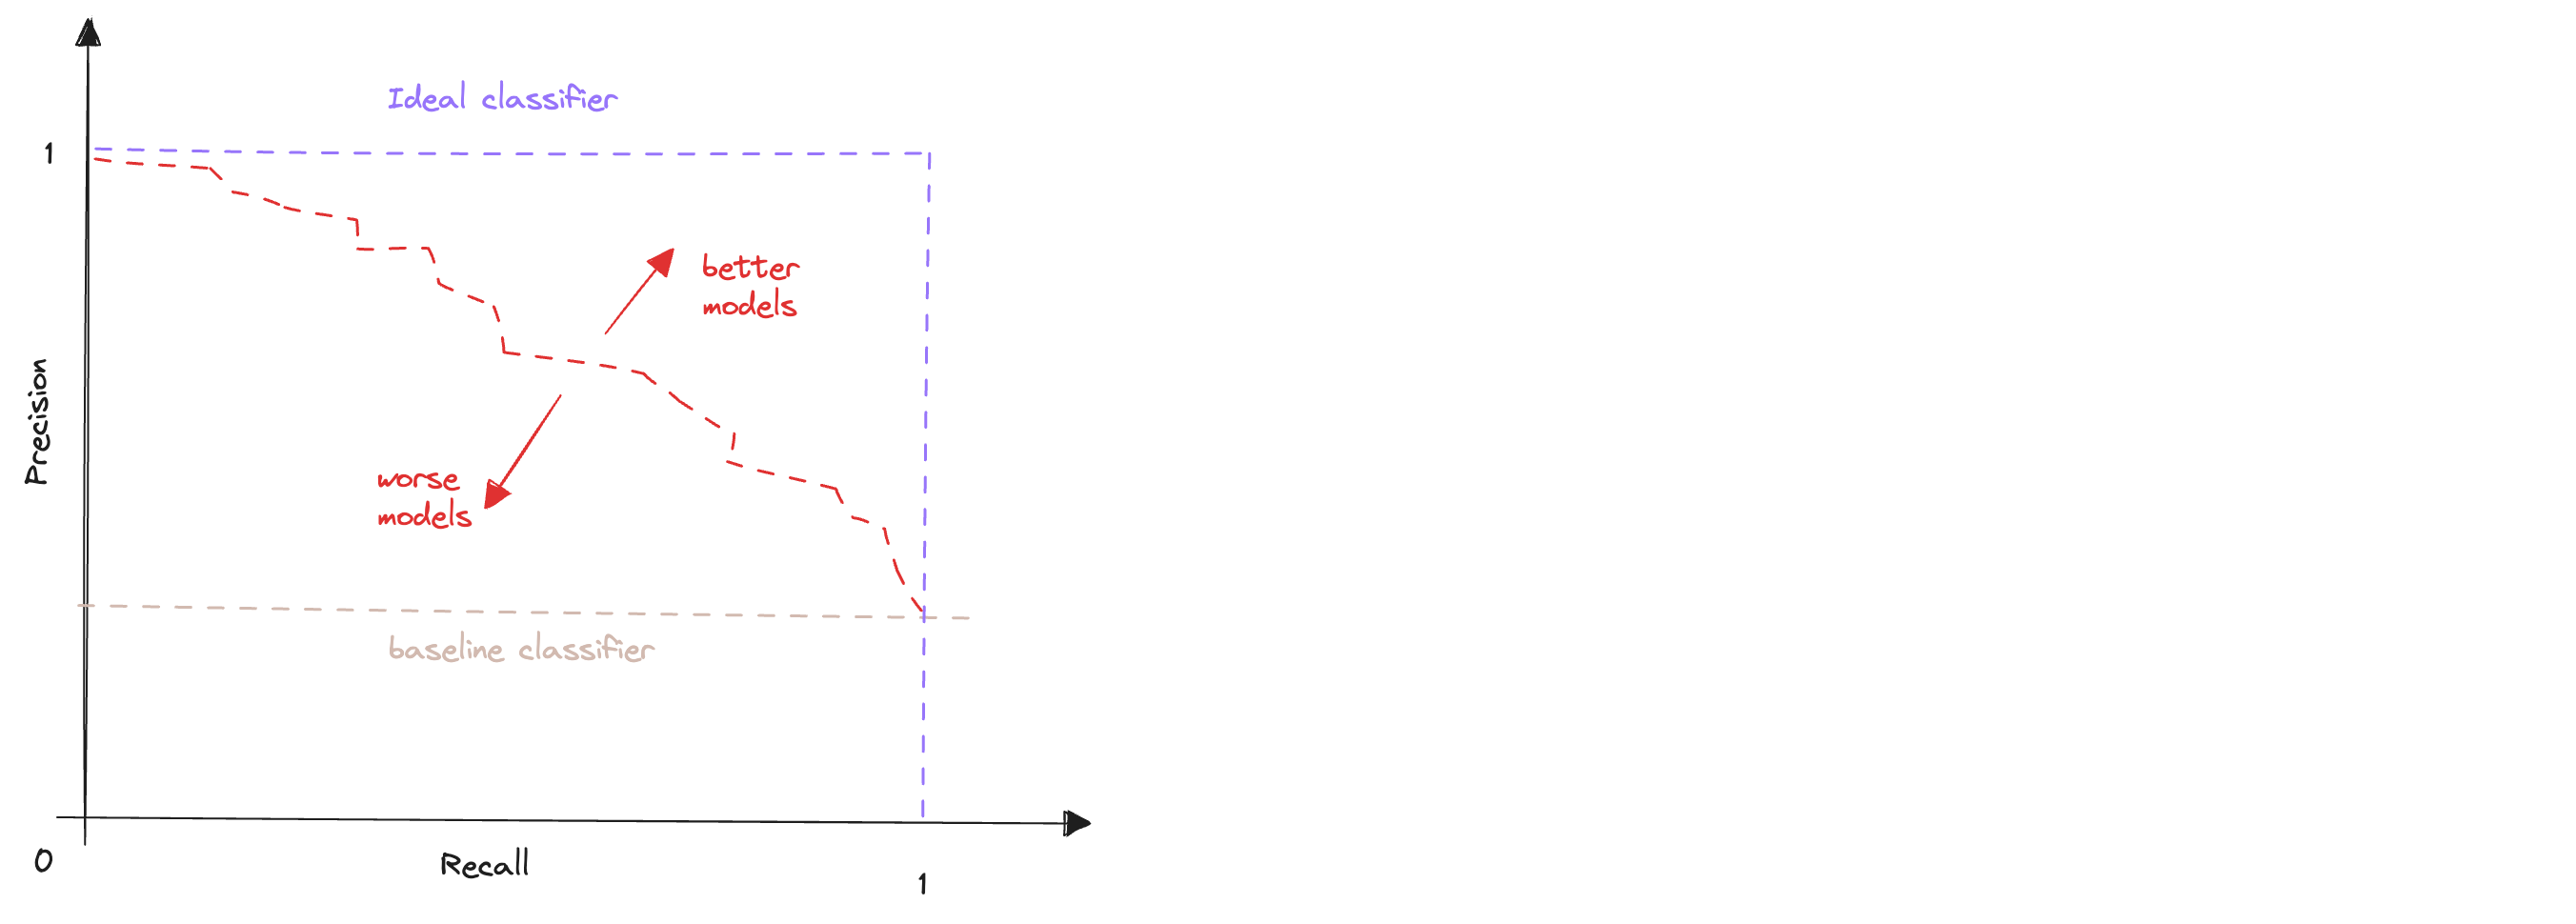

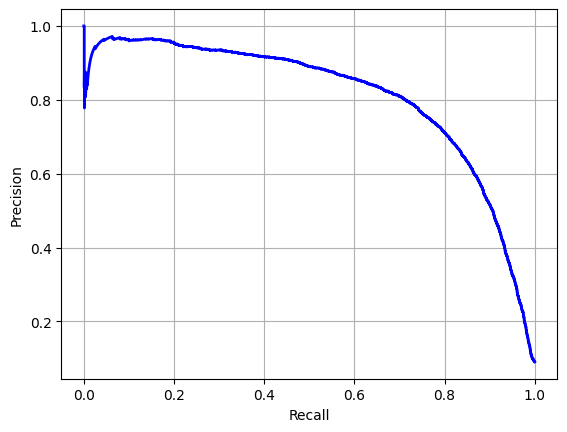

In [19]:
plt.plot(recalls, precisions, "b-", linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)

plt.show()

Precision starts to fall sharply around 80% recall. We will probably want to select a precision/recall trade-off just before that drop, for example at around 60% recall.  But of course, the choice depends on the project, we can search for the lowest threshold that gives at least 90% precision using the **np.argmax()** function which gives the first index of the maximum value.

In [20]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
print(threshold_90_precision)

y_train_pred_90 = (y_scores >= threshold_90_precision)
print(precision_score(y_train_5, y_train_pred_90))
print(recall_score(y_train_5, y_train_pred_90))

3370.0194991439566
0.9000345901072293
0.4799852425751706


As we can see, it is fairly easy **to create a classifier with virtually any precision we want**: just set a high enough threshold, and we have done. But **at what recall?**

### ROC Curve

The **receiver operating characteristic (ROC)** curve is another common tool
used with binary classifiers. It plots the **true positive rate** (the proportion of positives that are correctly identified, also colled **sensitivity**) against the **true negative rate (TNR)** (the proportion of negatives that are correctly identified, also called **specificity**)

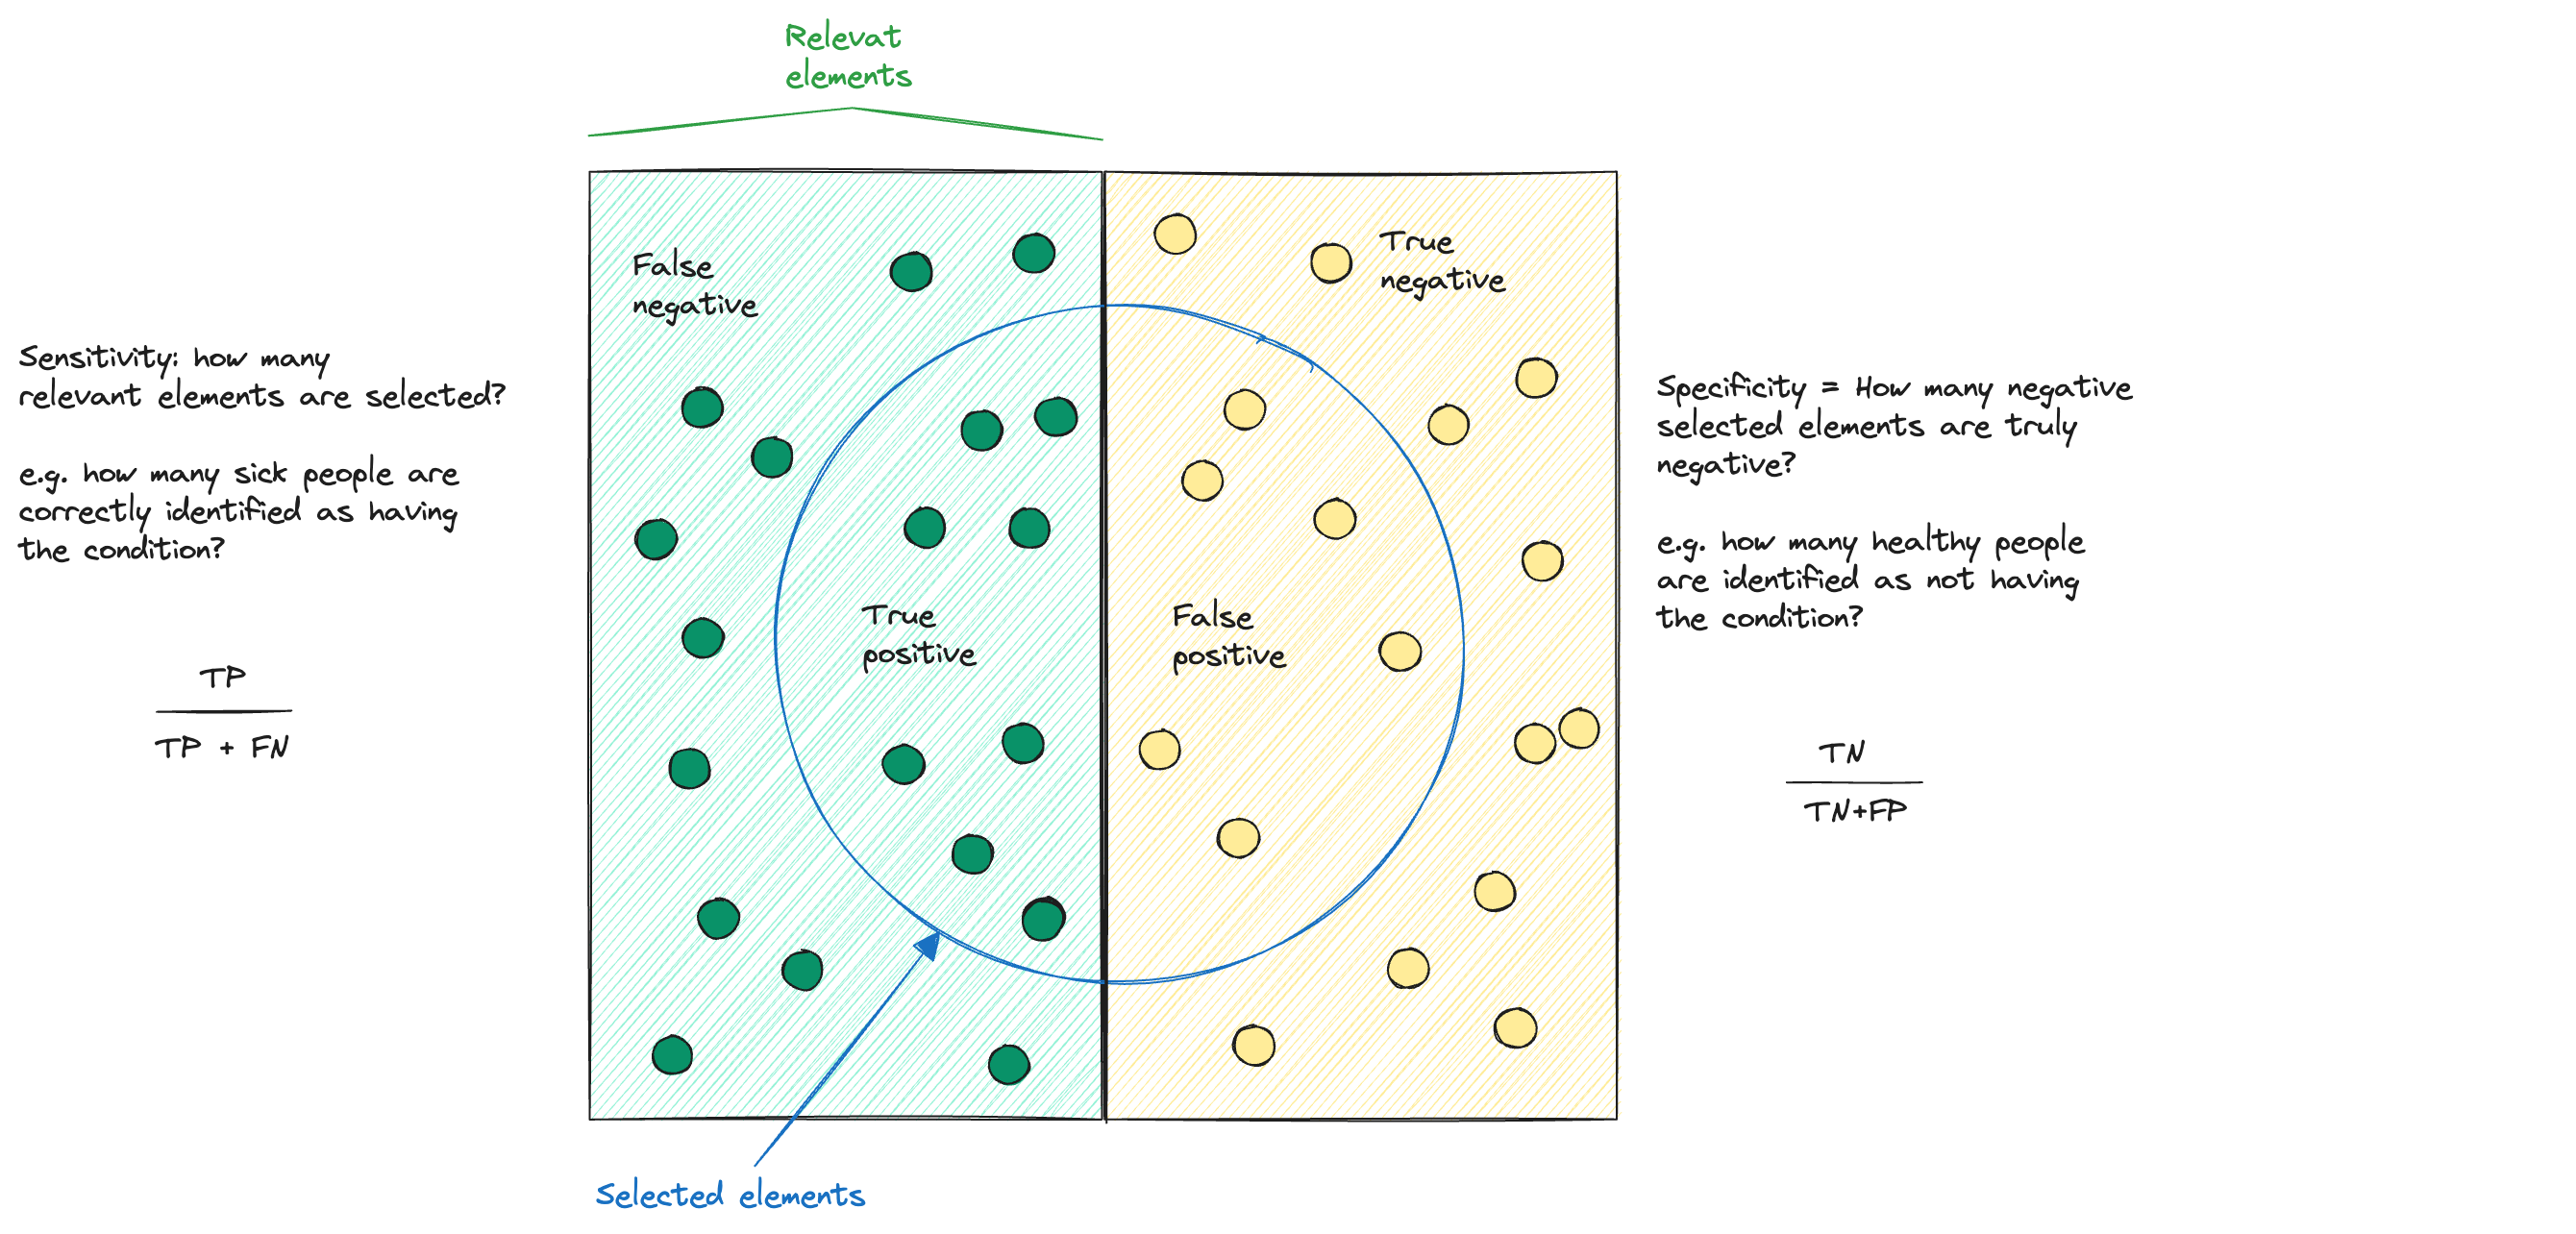

The following figure shows how some theoretical classifiers would plot on an ROC curve. The gray dotted line represents a classifier that is no better than random guessing, this will plot as a diagonal line. The purple line represents a perfect classifier, one with a true positive rate of 100% and a false positive rate of 0%. Nearly all real-world examples will fall somewhere between these two lines: not perfect, but providing more predictive power than random guessing. Typically, what we’re looking for is a classifier that maintains **a high true positive rate while also having a high true negative rate**. This ideal classifier would **“hug” the upper left corner** of the figure, much like the purple line.

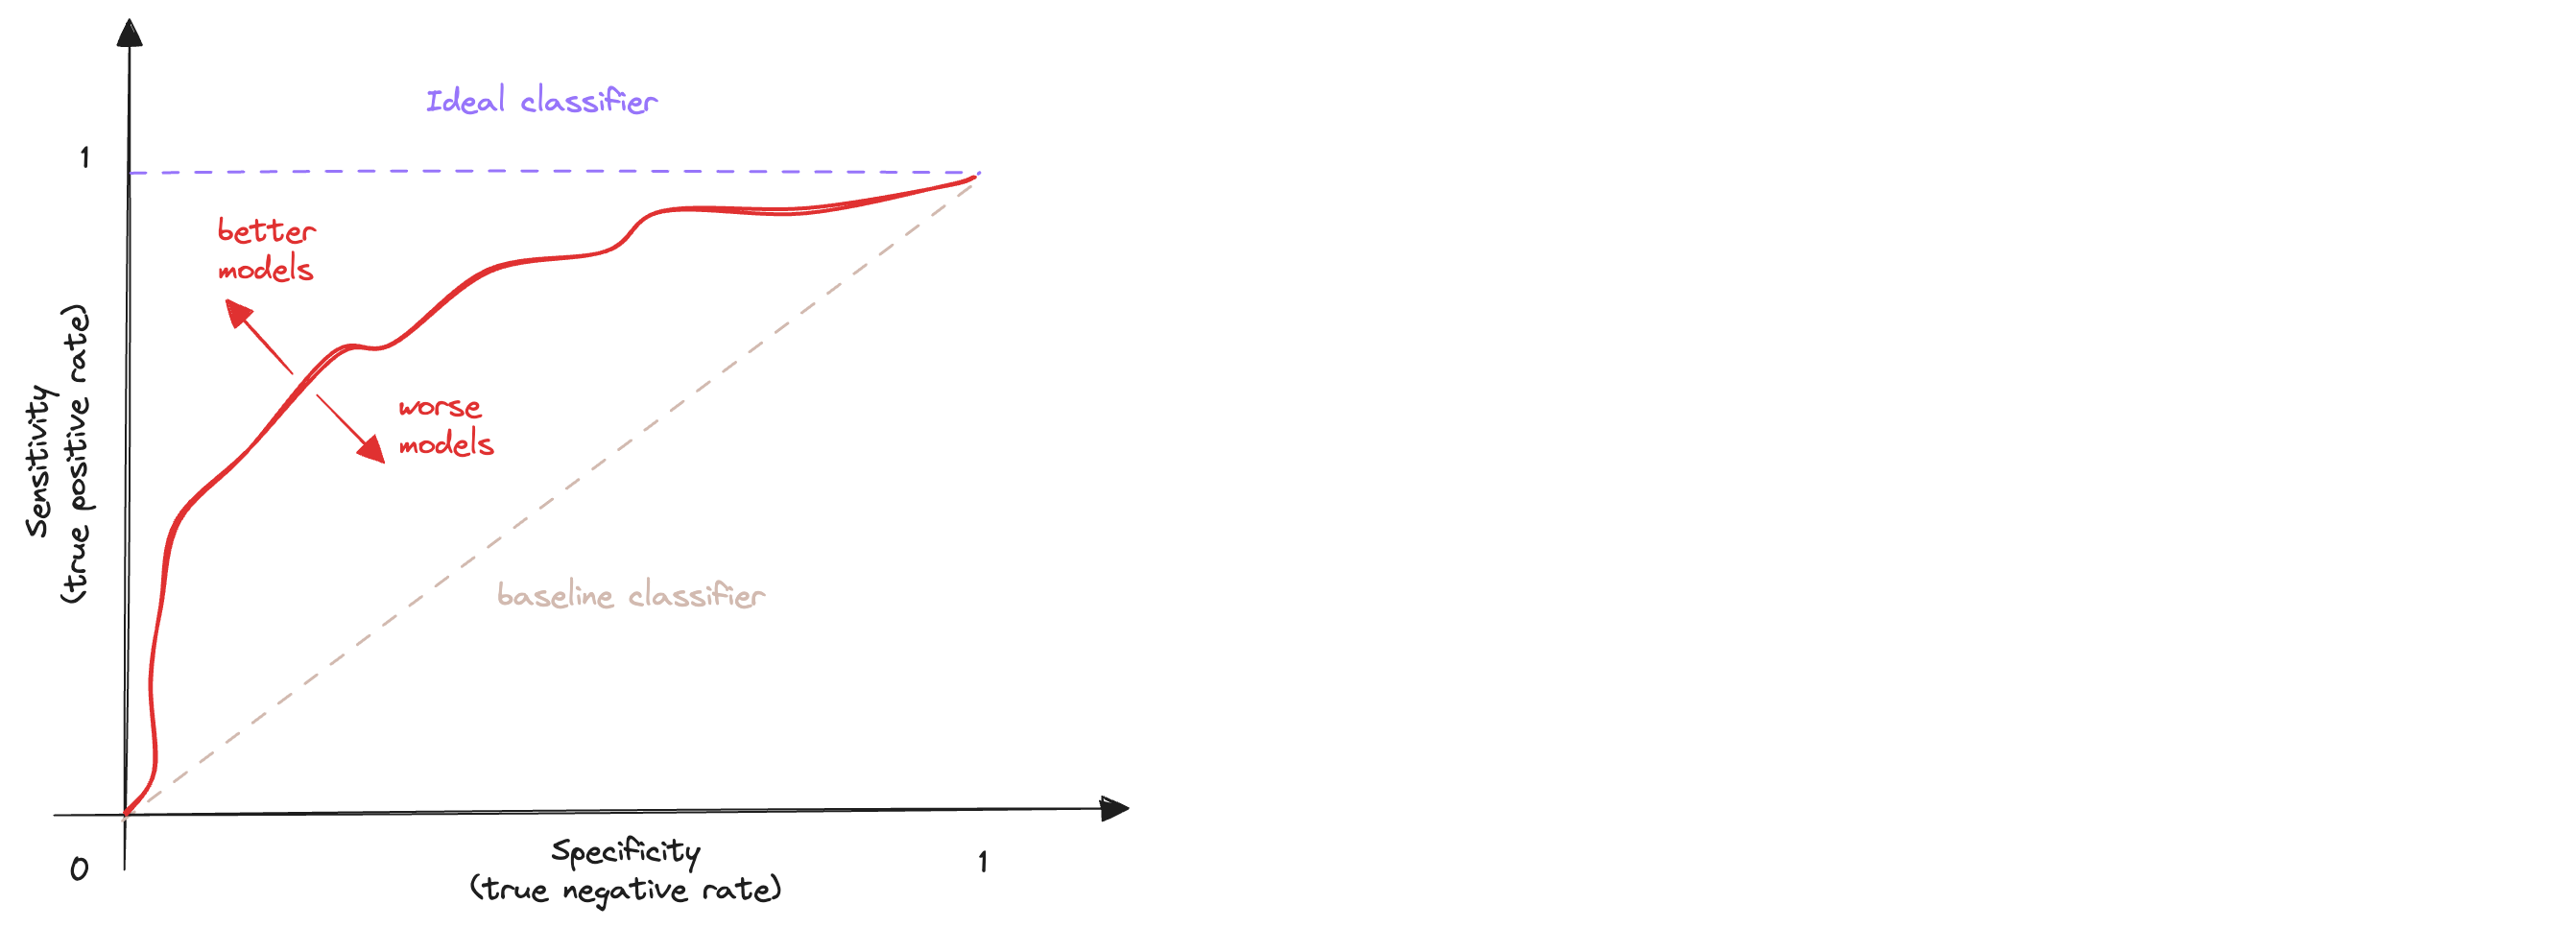

To plot the ROC curve, you first use the **roc_curve()** function to compute the TPR and FPR for various threshold values. Then you can plot the FPR against the TPR.

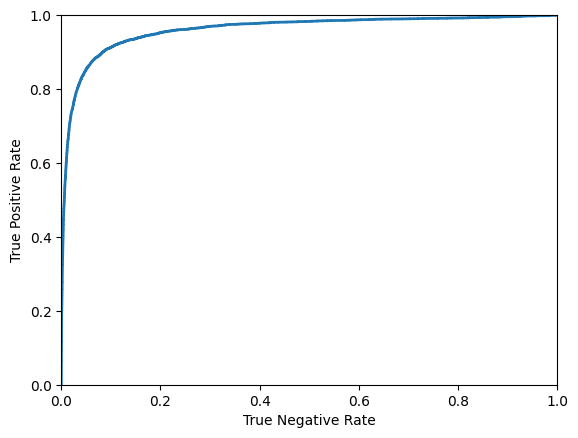

In [21]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

plt.plot(fpr, tpr, linewidth=2)
plt.axis([0, 1, 0, 1]) 
plt.xlabel('True Negative Rate')
plt.ylabel('True Positive Rate')
plt.show()                                            

Once again there is a trade-off: the higher the TPR, the more false positives the classifier produces and a lower TNR we have. One way to compare classifiers is to measure the **area under the curve** (AUC). A perfect classifier will have a ROC AUC equal to 1, whereas a purely random classifier will have a ROC AUC equal to 0.5.

In [22]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_train_5, y_scores))

0.9604938554008616


Since the ROC curve is so similar to the precision/recall curve, how to decide which one to use? As a rule of thumb, wē should **prefer the precision/recall curve whenever the positive class is rare or when we care more about the false positives than the false negatives**. Otherwise, use the ROC curve. In the example, looking at the ROC curve, you may think that the classifier is really good, but this is mostly because there are few positives compared to the negatives. In contrast, the precision-recall curve makes it clear that the classifier has room for improvement.

## Multiclass Classification

**Multiclass classifiers** can distinguish **between more than two classes**. Some algorithms are capable of handling multiple classes natively, others are strictly binary classifiers. However, there are strategies to perform multiclass classification with multiple binary classifiers.

One way is to train N binary classifiers (one for each class), then when we need to classify an element, we get the decision score from each classifier for that element and we select the class whose classifier outputs the highest score. This is called the **one-versus-the-rest strategy (OvR)** (also called **one-versus-all**). 

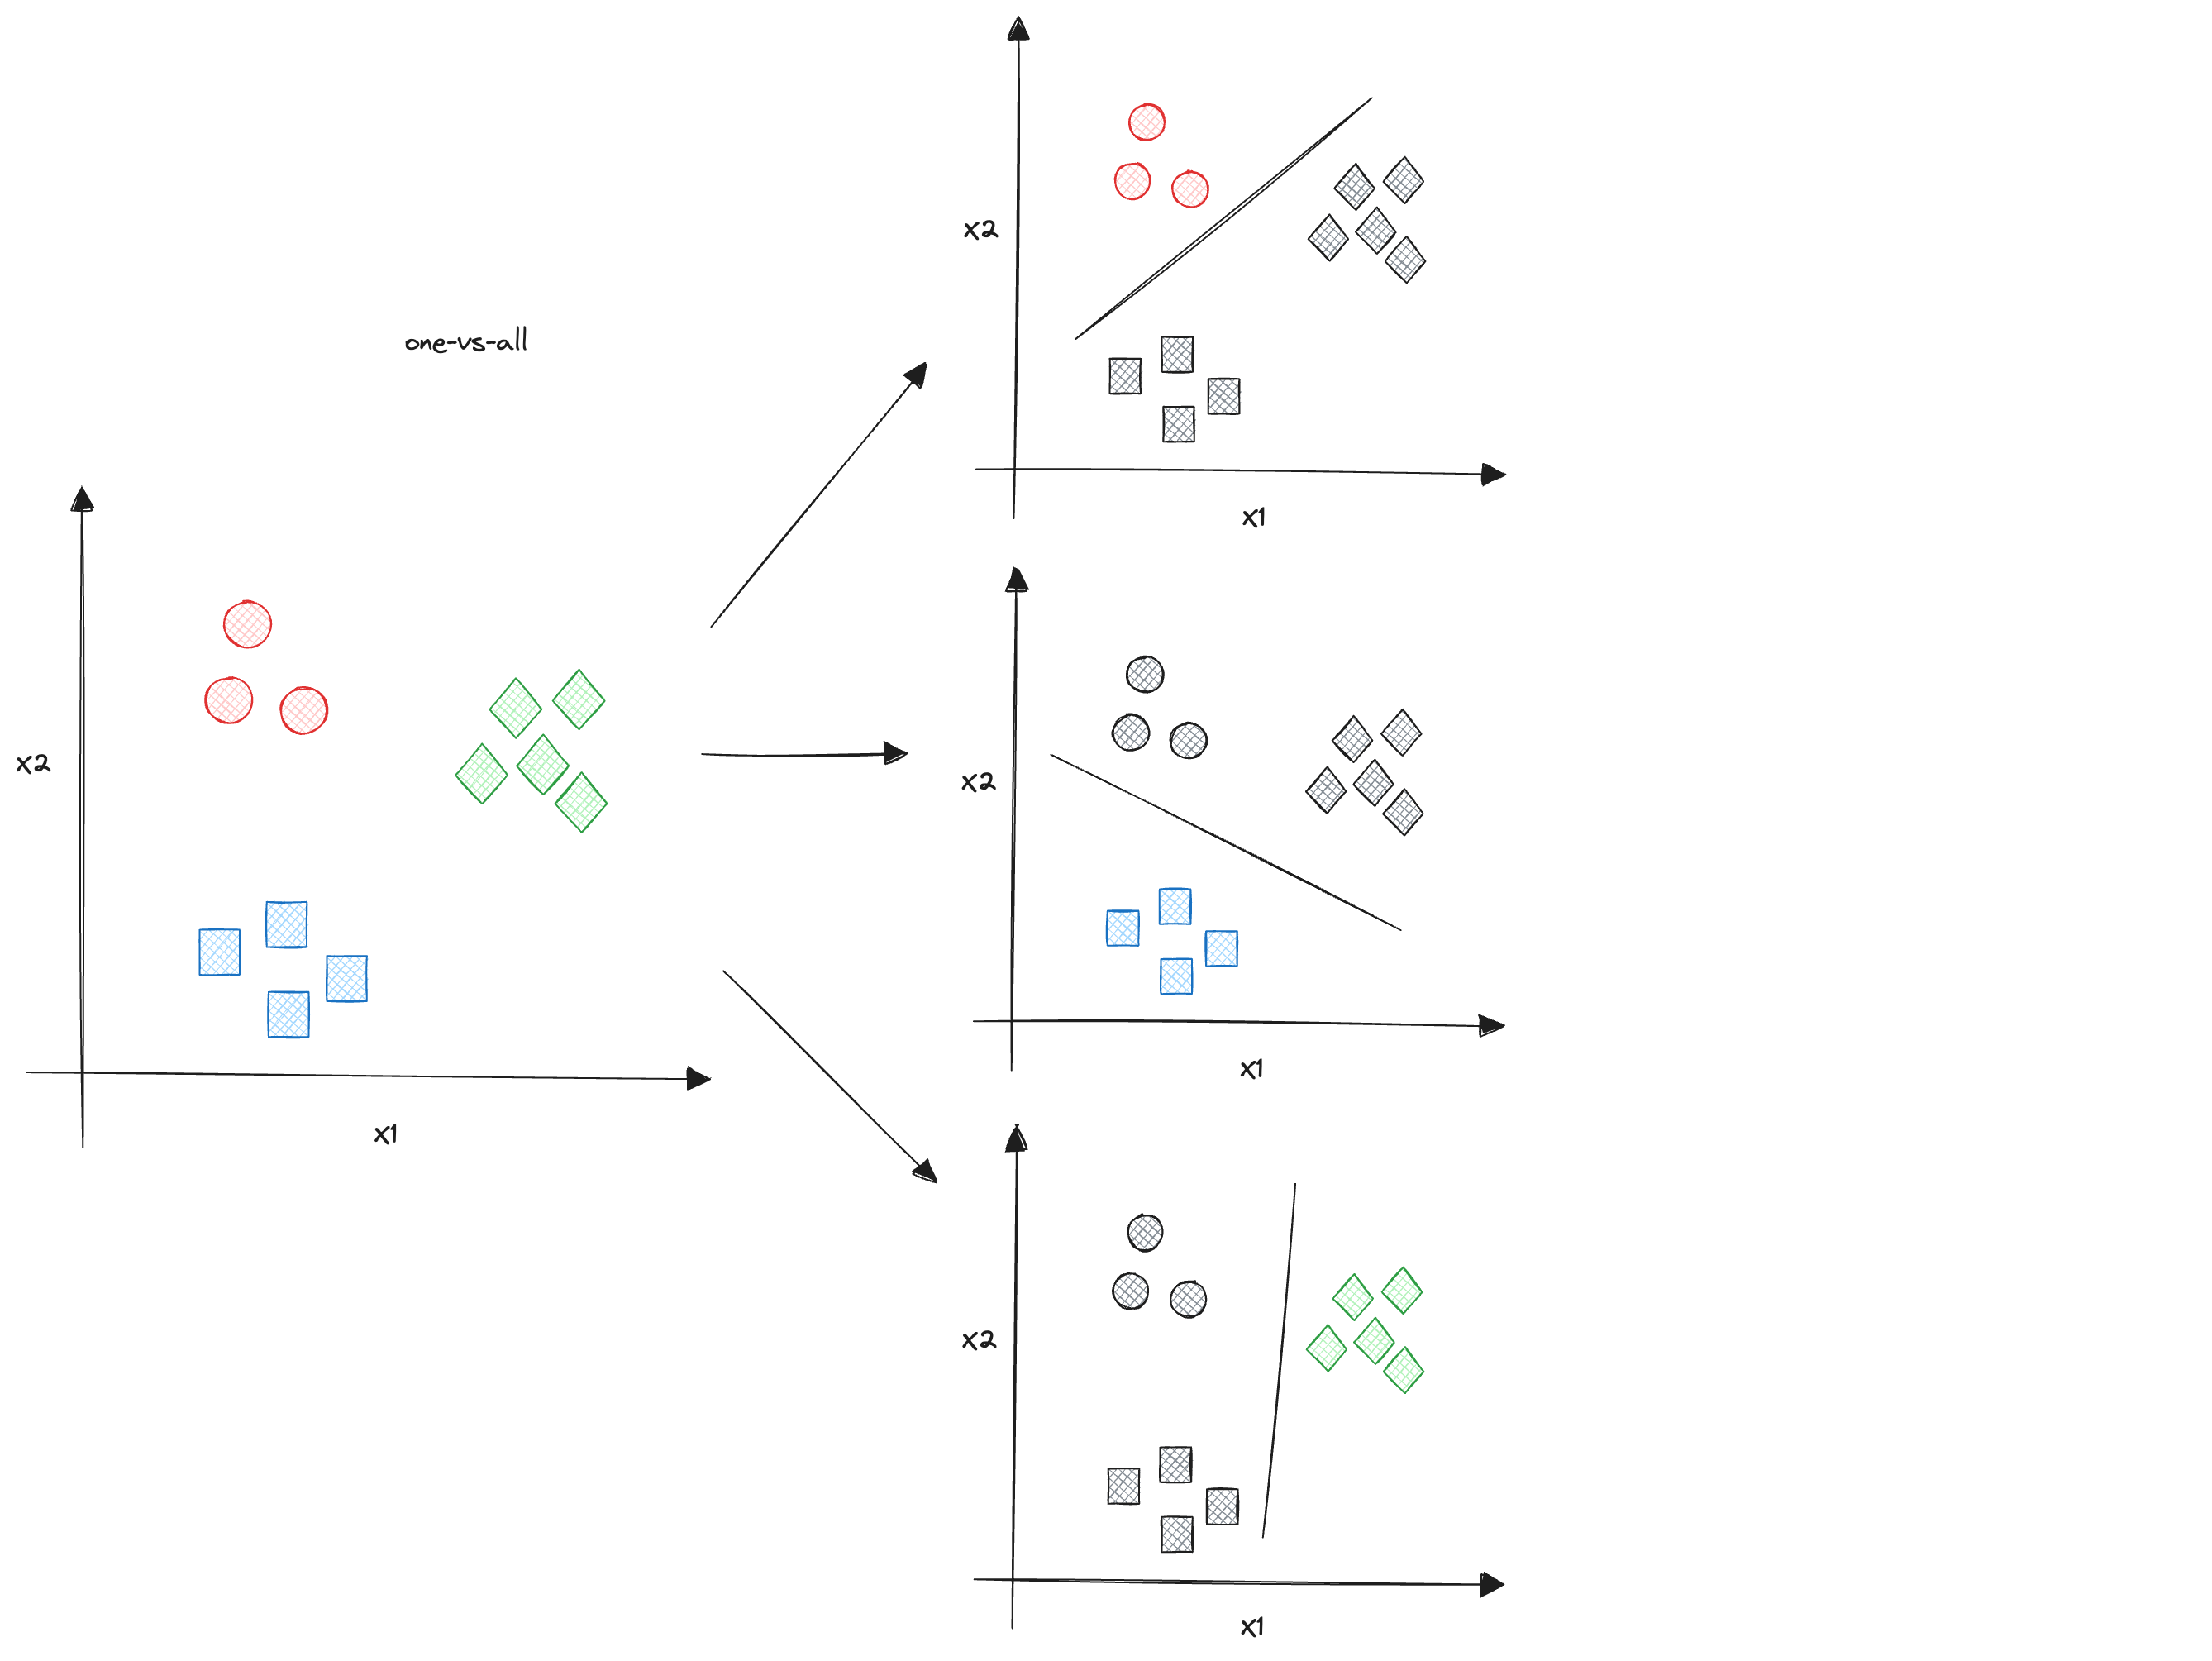

Another strategy is to train a binary classifier for every pair of classes. This is called the **one-versus-one strategy (OvO)**. If there are N classes, we need to train N×(N–1)/2 classifiers. When we want to classify an element, we have to run the element through all classifiers and see which class wins the most duels. The main advantage of OvO is that each classifier only needs to be trained on the part of the training set for the two classes that it must distinguish.

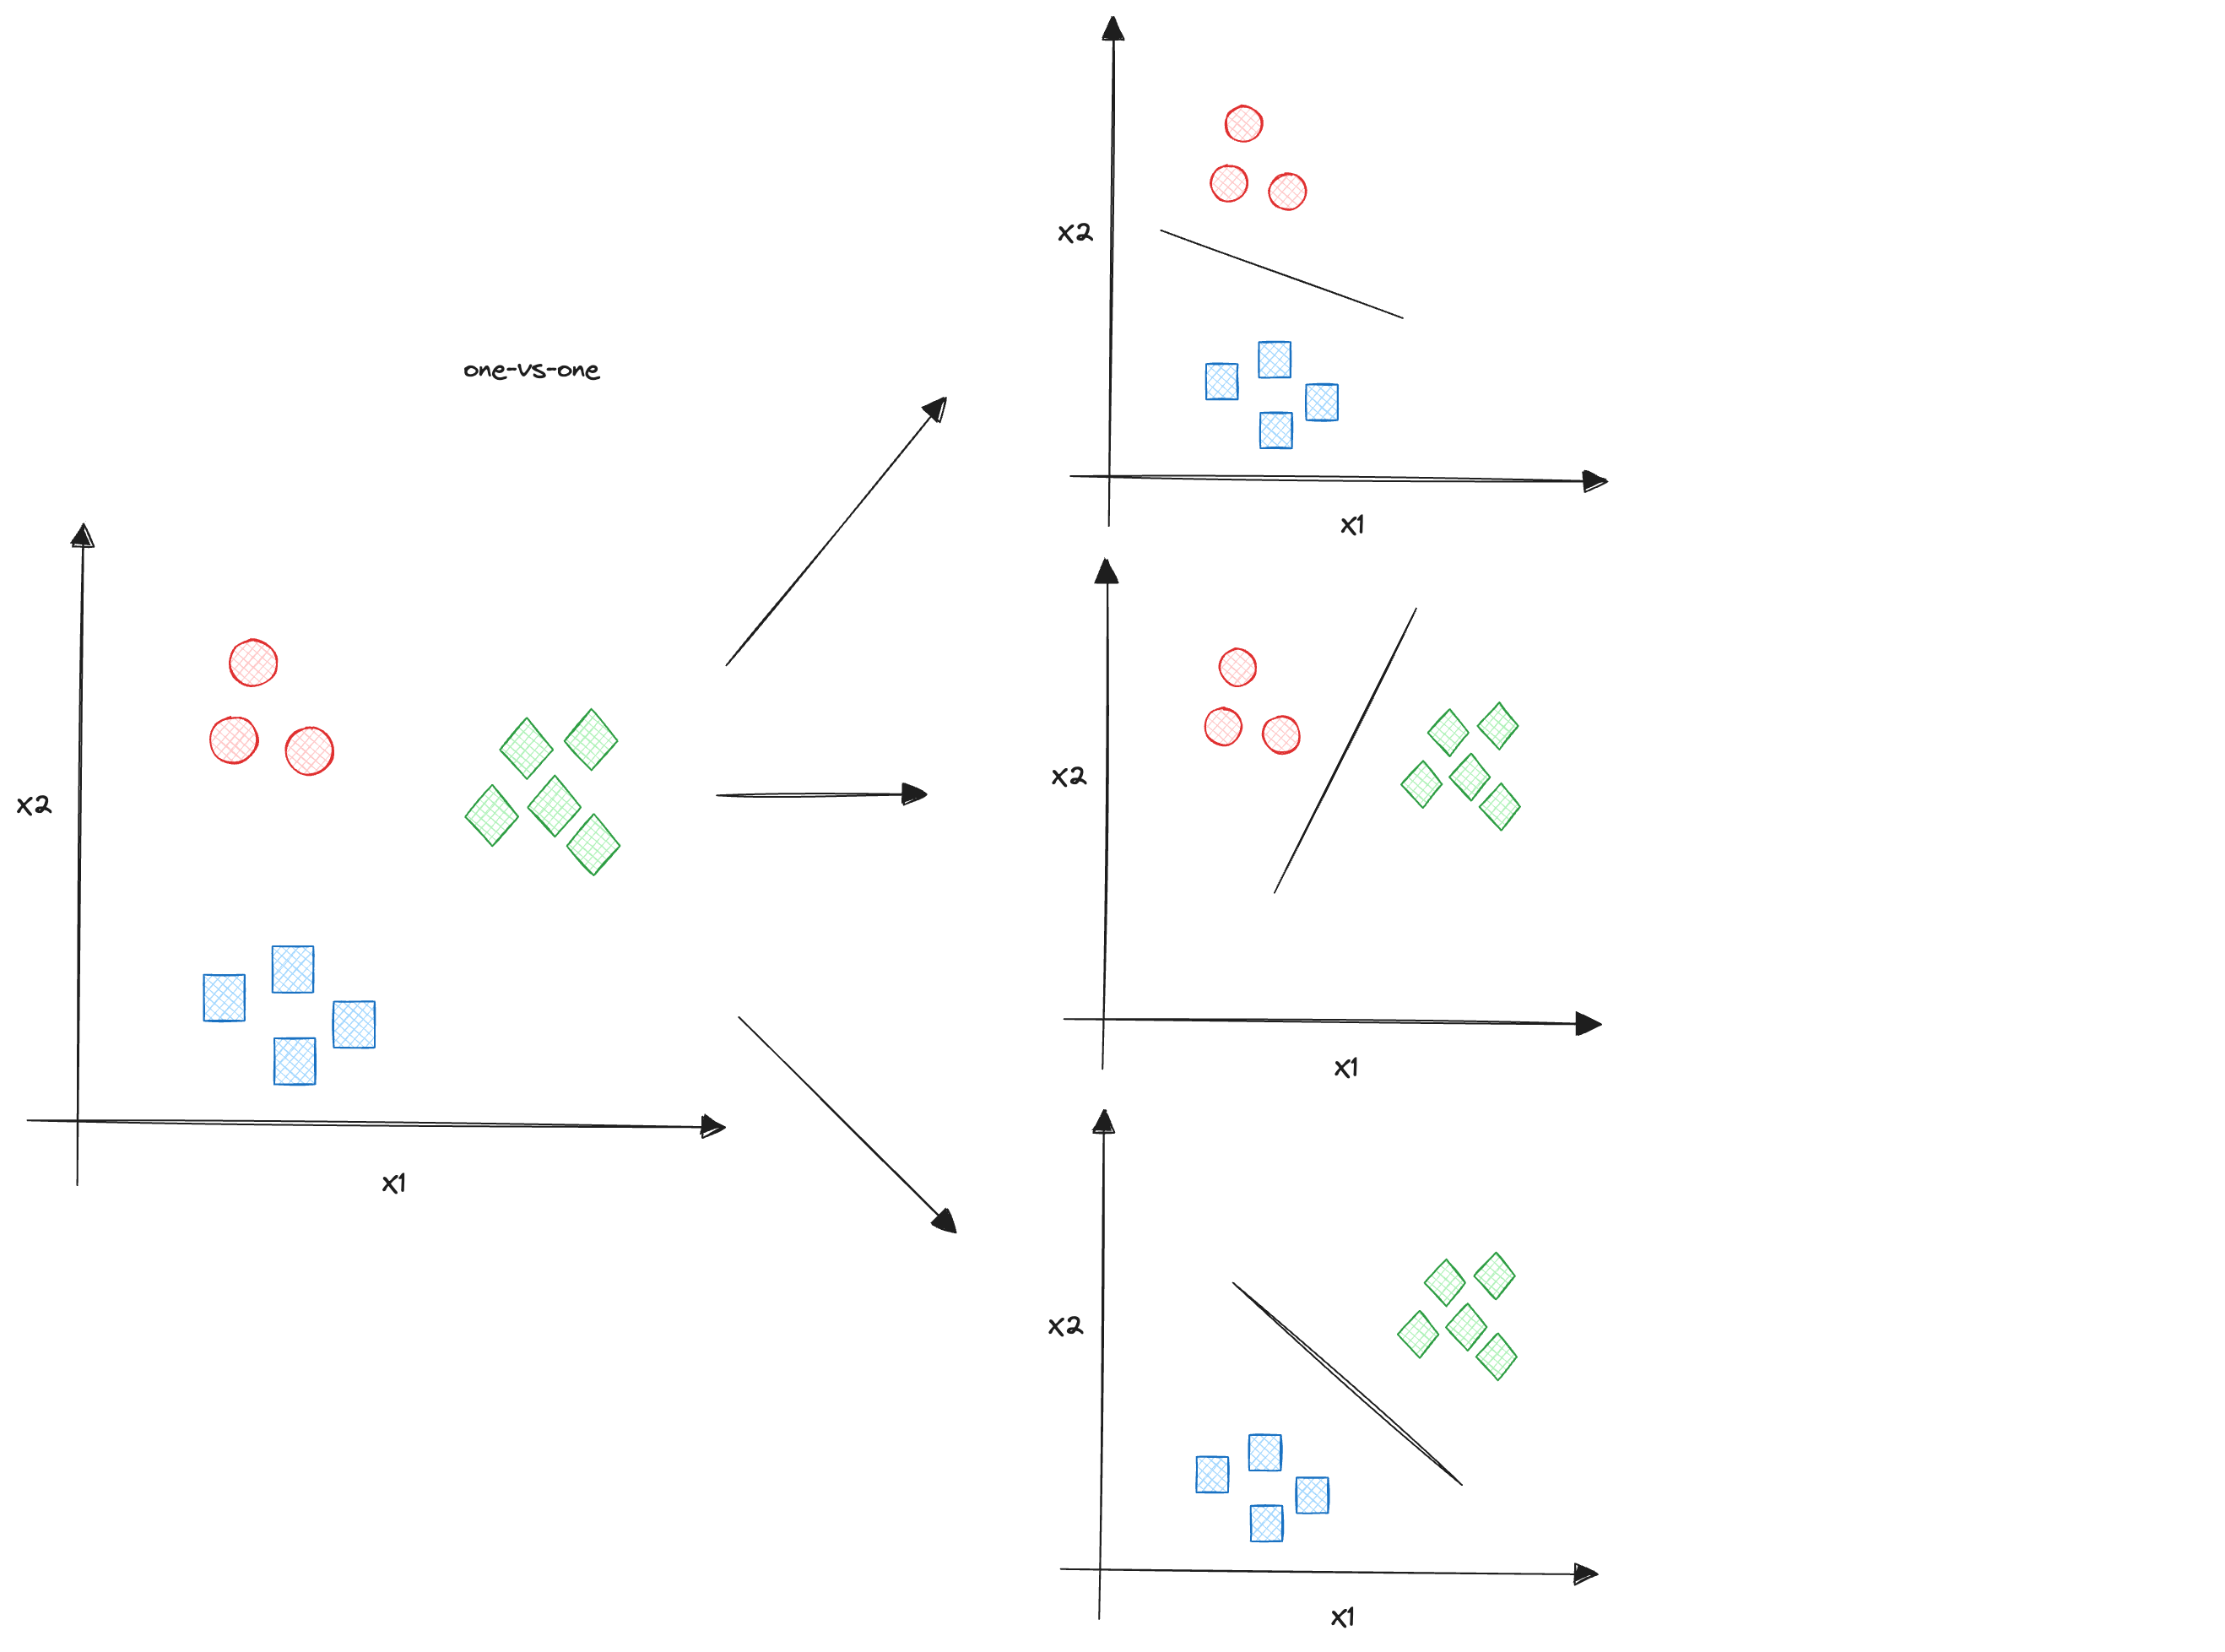

Scikit-Learn detects when you try to use a binary classification algorithm for a multiclass classification task, and it automatically runs OvR or OvO, depending on the algorithm. We can force Scikit-Learn to use one-versus-one or one-versus-all using the **OneVsOneClassifier** or **OneVsRestClassifier** classes.

Let’s try this with a Support Vector Machine classifier. 

In [23]:
from sklearn.svm import SVC

svm_clf = SVC()
svm_clf.fit(X_train, y_train)

svm_clf.predict([some_digit])

array([5], dtype=uint8)

In [24]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC())
ovr_clf.fit(X_train, y_train)
print(ovr_clf.predict([some_digit]))

[5]


If we call the **decision_function()** method, we can see that it returns the scores per class.

In [25]:
some_digit_scores = svm_clf.decision_function([some_digit])
print(some_digit_scores)

[[ 1.72501977  2.72809088  7.2510018   8.3076379  -0.31087254  9.3132482
   1.70975103  2.76765202  6.23049537  4.84771048]]


Training an SGDClassifier is just as easy.

In [26]:
sgd_clf.fit(X_train, y_train)
print(sgd_clf.predict([some_digit]))

[3]


Now of course we have to evaluate the classifier. As usual, we can use cross-validation.

In [27]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87365, 0.85835, 0.8689 ])

It gets over 85% on all test folds. If we used a random classifier, we would get 10% accuracy, so this is not such a bad score. We can look at the confusion matrixs for the two classifiers in order to analyze the types of errors it makes. 

In [28]:
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)
conf_mx_sgd = confusion_matrix(y_train, y_train_pred)
print("Confusion Matrix SGD:")
print(conf_mx_sgd)

Confusion Matrix SGD:
[[5635    0   61   10   16   50   46    7   66   32]
 [   3 6393   95   21   16   47   15   27  109   16]
 [  72   56 5174   89   69   39  163   66  212   18]
 [  58   32  217 4941   23  441   32   56  216  115]
 [  11   26   46    6 5298   26   73   32   87  237]
 [  68   23   58  150   83 4606  174   26  152   81]
 [  40   13   56    6   22  113 5625    5   36    2]
 [  23   24  103   36  124   40   10 5228   75  602]
 [  40  101  158  122   49  457   77   35 4666  146]
 [  33   18   66   83  515  127    4  485  166 4452]]


In [29]:
y_train_pred = cross_val_predict(svm_clf, X_train, y_train, cv=3)
conf_mx_svm = confusion_matrix(y_train, y_train_pred)
print("Confusion Matrix SVM:")
print(conf_mx_svm)

Confusion Matrix SVM:
[[5863    3   10    2    4    8   14    2   13    4]
 [   1 6664   26    9   10    1    3   10   10    8]
 [  19    9 5811   16   26    5    8   30   28    6]
 [   3    9   54 5891    2   62    1   30   61   18]
 [   5   11   13    0 5712    0   20    9    4   68]
 [  11    6   10   57   14 5255   35    4   17   12]
 [  20    8    7    0   10   32 5831    0   10    0]
 [   5   21   42    6   35    2    1 6100    7   46]
 [   8   29   19   38   20   39   21    9 5646   22]
 [  14   11    4   31   72   16    2   59   19 5721]]


That’s a lot of numbers. It’s often **more convenient to look at an image representation of the confusion matrix**, using Matplotlib’s **matshow()** function

Confusion Matrix SGD:
Confusion Matrix SVM:


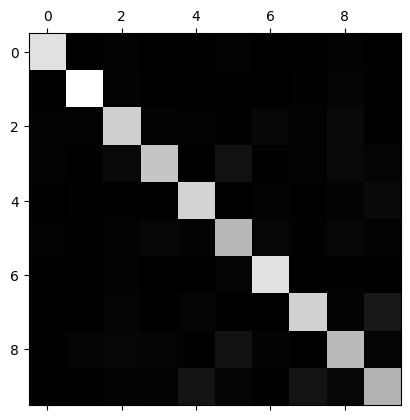

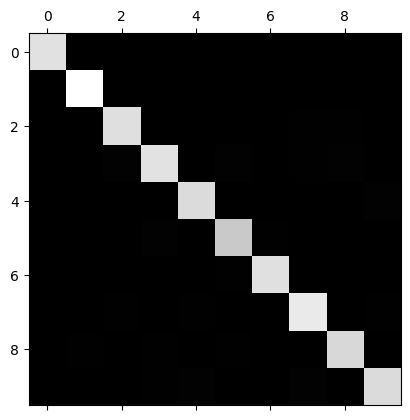

In [30]:
print("Confusion Matrix SGD:")
plt.matshow(conf_mx_sgd, cmap=plt.cm.gray)

print("Confusion Matrix SVM:")
plt.matshow(conf_mx_svm, cmap=plt.cm.gray)

plt.show()

The confusion matrix looks pretty good, since **most images are on the main diagonal, which means that they were classified correctly**. The 5s look slightly darker than the other digits, this which could mean that there are fewer images of 5s in the dataset or that the classifier does not perform as well on 5s as on other digits. We can verify that both are the case. Let’s **focus the plot on the errors**. We need to divide each value in the confusion matrix by the number of images in the corresponding class so that **we can compare error rates instead of absolute numbers** of errors. Then we fill the diagonal with zeros to keep only the errors.

Confusion Matrix SGD, focus on errors:
Confusion Matrix SVM, focus on errors:


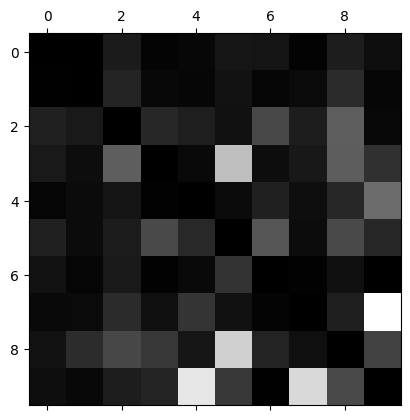

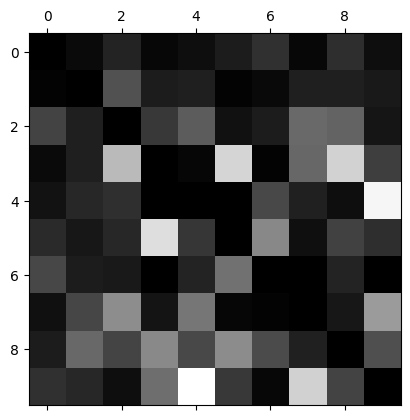

In [31]:
row_sums_sgd = conf_mx_sgd.sum(axis=1, keepdims=True)
norm_conf_mx_sgd = conf_mx_sgd / row_sums_sgd
np.fill_diagonal(norm_conf_mx_sgd, 0)

row_sums_svm = conf_mx_svm.sum(axis=1, keepdims=True)
norm_conf_mx_svm = conf_mx_svm / row_sums_svm
np.fill_diagonal(norm_conf_mx_svm, 0)

print("Confusion Matrix SGD, focus on errors:")
plt.matshow(norm_conf_mx_sgd, cmap=plt.cm.gray)

print("Confusion Matrix SVM, focus on errors:")
plt.matshow(norm_conf_mx_svm, cmap=plt.cm.gray)

plt.show()

We can see the kinds of errors the classifier makes. The column for class 8 is quite bright, which tells us that many images get misclassified as 8s. However, the row for class 8 is not that bad, telling us that actual 8s in general get properly classified as 8s. We can also see that 3s and 5s often get confused (in both directions). **Analyzing individual errors can also be a good way to gain insights on what the classifier is doing and why it is failing**, but it is more difficult and
time-consuming. For example, let’s plot examples of 3s and 5s.

In [36]:
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap = "binary", **options)
    plt.axis("off")

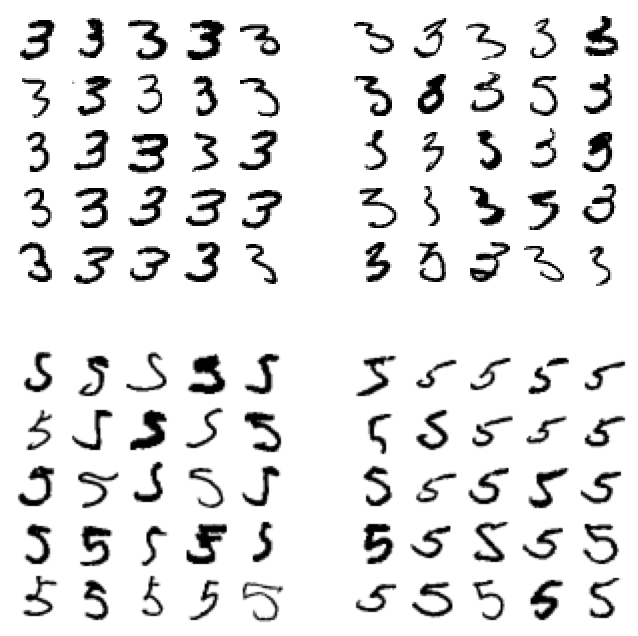

In [37]:
cl_a, cl_b = 3, 5

X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

plt.figure(figsize=(8,8))

plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5)
plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5)
plt.subplot(223); plot_digits(X_ba[:25], images_per_row=5)
plt.subplot(224); plot_digits(X_bb[:25], images_per_row=5)

plt.show()

The two blocks on the left show digits classified as 3s, and the two blocks on the right show images classified as 5s.  Some of the digits that the classifier gets wrong are so badly written that even a human would have trouble classifying them. However, most misclassified images seem like obvious errors to us, and **it’s hard to understand why the classifier made the mistakes it did**. The reason is that we used a simple SGD classifier, which is a linear model. All it does is assign a weight per class to each pixel, and when it sees a new image it just sums up the weighted pixel intensities to get a score for each class. So since 3s and 5s differ only by a few pixels, this model will easily confused by them.

## Multilabel Classification

Until now, each instance has always been assigned to just one class. In some cases we may want our classifier to **output multiple classes for each instance**.  Let’s look at a simple example. This code creates a y_multilabel array containing two target labels for each digit image: the first indicates whether or not the digit is large (7, 8, or 9), and the second indicates whether or not it is odd.

In [38]:
y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

Then we create a **KNeighborsClassifier** (which supports multilabel classification) and we train it. Notice that it outputs two labels.

In [39]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

print(knn_clf.predict([some_digit]))

[[False  True]]


There are many ways to evaluate a multilabel classifier, and **selecting the right metric really depends on the project**. One approach is to measure the F1 score for each individual label, then simply compute the average score ("macro"). This assumes that all labels are equally important, however, which may not be the case. To do*a weighted average (using the number of true instances for each label) set average="weighted".

In [40]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

print(f1_score(y_multilabel, y_train_knn_pred, average="macro"))

0.976410265560605


## Multioutput Classification

It is a generalization where **we have multilabel and each label can be multiclass** (i.e., it can have more than two possible values). To illustrate this, we build a system that removes noise from images. It will take as input a noisy digit image, and it will output a clean digit image, represented as an array of pixel intensities. Notice that the classifier’s output is multilabel (one label per pixel) and each label can have multiple values (pixel intensity ranges from 0 to 255).  Let’s start by creating the training and test sets by taking the MNIST images and adding noise to their pixel intensities with NumPy’s **randint()** function.

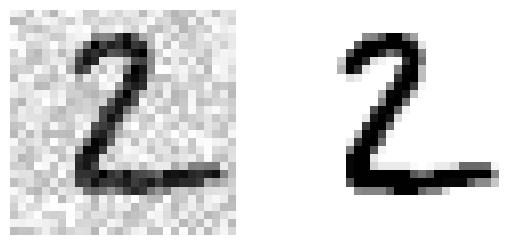

In [42]:
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
y_train_mod = X_train

noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_test_mod = X_test

def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = "binary", interpolation="nearest")
    plt.axis("off")
    
some_index = 1
plt.subplot(121); plot_digit(X_test_mod[some_index])
plt.subplot(122); plot_digit(y_test_mod[some_index])
plt.show()

Now let’s train the classifier and make it clean this image.

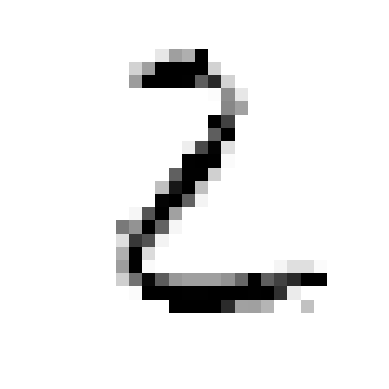

In [44]:
knn_clf.fit(X_train_mod, y_train_mod)

clean_digit = knn_clf.predict([X_test_mod[some_index]])
plot_digit(clean_digit)

## Exercise

**1. Try to build a classifier for the MNIST dataset that achieves over 97% accuracy on the test set. Hint: the KNeighborsClassifier works quite well for this task; you just need to find good hyperparameter values (try a grid search on the weights and n_neighbors hyperparameters).**

**Warning**: the next cell may take hours to run, depending on your hardware.

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = [{ 'weights': ["uniform", "distance"], 
                'n_neighbors': [3, 4, 5] }]

knn_clf = KNeighborsClassifier()

grid_search = GridSearchCV(knn_clf, param_grid, cv=5, verbose=0)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [3, 4, 5],
                          'weights': ['uniform', 'distance']}])

In [46]:
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [47]:
grid_search.best_score_

0.9716166666666666

In [48]:
from sklearn.metrics import accuracy_score

y_pred = grid_search.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9714


**2 - Write a function that shifts an MNIST image in any direction (left, right, up, or down) by one pixel. Then, for each image in the training set, create four shifted copies (one per direction) and add them to the training set. Finally, train your best model on this expanded training set and measure its accuracy on the test set. You should observe that your model performs even better now! This technique of artificially growing the training set is called data augmentation or training set expansion.**

In [50]:
from scipy.ndimage import shift

In [51]:
def shift_image(image, dx, dy):
    image = image.reshape((28, 28))
    shifted_image = shift(image, [dy, dx], cval=0, mode="constant")
    return shifted_image.reshape([-1])

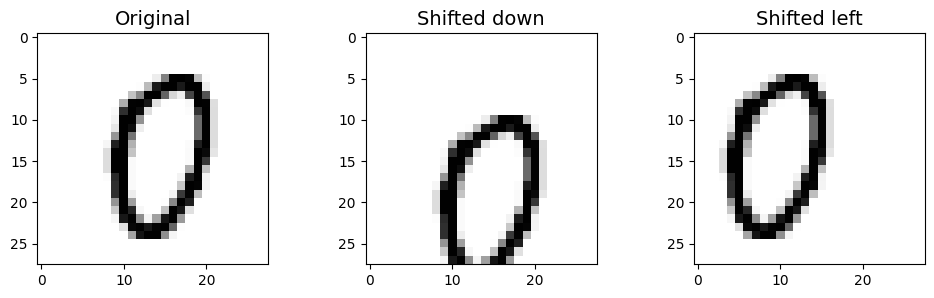

In [52]:
image = X_train[1000]
shifted_image_down = shift_image(image, 0, 5)
shifted_image_left = shift_image(image, -5, 0)

plt.figure(figsize=(12,3))

plt.subplot(131)
plt.title("Original", fontsize=14)
plt.imshow(image.reshape(28, 28), interpolation="nearest", cmap="Greys")

plt.subplot(132)
plt.title("Shifted down", fontsize=14)
plt.imshow(shifted_image_down.reshape(28, 28), interpolation="nearest", cmap="Greys")

plt.subplot(133)
plt.title("Shifted left", fontsize=14)
plt.imshow(shifted_image_left.reshape(28, 28), interpolation="nearest", cmap="Greys")

plt.show()

In [53]:
X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]

for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
    for image, label in zip(X_train, y_train):
        X_train_augmented.append(shift_image(image, dx, dy))
        y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

In [54]:
shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

In [55]:
knn_clf = KNeighborsClassifier(**grid_search.best_params_)

In [56]:
knn_clf.fit(X_train_augmented, y_train_augmented)

KNeighborsClassifier(n_neighbors=4, weights='distance')

In [57]:
y_pred = knn_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9763

By simply augmenting the data, we got some accuracy boost.